# Classical ML for the Threat Intelligence Lifecycle

This notebook demonstrates six ML use cases, each mapped to a stage of the intelligence cycle built across Chapters 6–12 — and each grounded in the ApexCode AiTM incident that drove those chapters. After the Stage 7 feedback, ApexCode's CISO surfaced two follow-on concerns; the analyst's decomposition produced three operational sub-questions plus a forward-looking forecast. The experiments below show how classical ML answers them.

| Section | Stage | ML Use Case | ApexCode Question |
|---|---|---|---|
| 1 | Collection (Ch 7) | CVE prioritization for triage | Which CVEs in our partner vendor surface area should the collection team triage first? |
| 2 | Analysis (Ch 9) | Exploitation detection (binary classification) | Which CVEs are actively being exploited right now? |
| 3 | Analysis (Ch 9) | Actor TTP clustering (hypothesis-set generation) | Which known actor groups have TTPs most similar to the AiTM campaign — before ACH? |
| 4 | Production (Ch 10) | Exploitation likelihood + SHAP attribution | Why did this CVE score high, and what should we patch first? |
| 5 | Feedback (Ch 12) | Vulnerability disclosure forecasting | Is session-hijacking CVE disclosure trending up? How much capacity should we allocate next quarter? |
| 6 | Analysis (Ch 9) | ACH argument map (matrix + Sankey) | Which of the three competing hypotheses does the evidence best support? |

**Data sources:** CISA KEV (known exploited vulnerabilities), NVD CVE database (2020–2025), MITRE ATT&CK STIX.  
All responses are cached to `./data/` so subsequent runs skip the API calls.


In [1]:
import os, json, time, warnings
from pathlib import Path
from datetime import datetime, timedelta, date

import requests
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    brier_score_loss, precision_score
)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("WARNING: shap not installed. Run: pip install shap")

warnings.filterwarnings('ignore')

CACHE_DIR = Path('data')
CACHE_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)
print(f"Setup complete. Cache: {CACHE_DIR.resolve()}")
print(f"Images:         {IMAGES_DIR.resolve()}")
print(f"SHAP available: {SHAP_AVAILABLE}")


Setup complete. Cache: /Users/austinn/Desktop/Packt Chapter Work/Chap_13/data
Images:         /Users/austinn/Desktop/Packt Chapter Work/Chap_13/images
SHAP available: True


In [2]:
!pip install shap xgboost lightgbm


In [3]:
# ── Data Loading Utilities ────────────────────────────────────────────────────

def fetch_kev(force=False):
    """Download CISA Known Exploited Vulnerabilities catalog. Cached to data/kev.json."""
    cache = CACHE_DIR / 'kev.json'
    if cache.exists() and not force:
        data = json.loads(cache.read_text())
        print(f"KEV loaded from cache: {len(data['vulnerabilities'])} entries")
        return data
    url = 'https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json'
    print("Downloading CISA KEV...")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()
    cache.write_text(json.dumps(data))
    print(f"KEV downloaded: {len(data['vulnerabilities'])} entries")
    return data


def fetch_nvd_year(year, api_key=None, force=False):
    """
    Download all CVEs published in a given year from NVD 2.0 API.
    Chunked into 90-day windows (API enforces 120-day max range).
    Cached to data/nvd_{year}.json.
    """
    cache = CACHE_DIR / f'nvd_{year}.json'
    if cache.exists() and not force:
        cves = json.loads(cache.read_text())
        print(f"NVD {year} loaded from cache: {len(cves)} CVEs")
        return cves

    from datetime import date, timedelta
    base_url = 'https://services.nvd.nist.gov/rest/json/cves/2.0'
    headers = {'apiKey': api_key} if api_key else {}
    sleep_sec = 2 if api_key else 7

    # Build 90-day windows covering the full year
    windows = []
    win_start = date(year, 1, 1)
    year_end  = date(year, 12, 31)
    while win_start <= year_end:
        win_end = min(win_start + timedelta(days=89), year_end)
        windows.append((win_start, win_end))
        win_start = win_end + timedelta(days=1)

    all_cves = []
    print(f"Downloading NVD {year} in {len(windows)} windows...", flush=True)
    for ws, we in windows:
        start_str = ws.strftime('%Y-%m-%dT00:00:00.000')
        end_str   = we.strftime('%Y-%m-%dT23:59:59.999')
        idx, total = 0, None
        while total is None or idx < total:
            params = dict(pubStartDate=start_str, pubEndDate=end_str,
                          resultsPerPage=2000, startIndex=idx)
            r = requests.get(base_url, params=params, headers=headers, timeout=60)
            if r.status_code == 403:
                print("  Rate limited — sleeping 35s..."); time.sleep(35); continue
            r.raise_for_status()
            data = r.json()
            total = data['totalResults']
            batch = data.get('vulnerabilities', [])
            all_cves.extend(batch)
            idx += len(batch)
            if idx < total:
                time.sleep(sleep_sec)
        print(f"  {ws}→{we}: {total} CVEs", flush=True)
        time.sleep(sleep_sec)

    print(f"NVD {year}: {len(all_cves)} CVEs total")
    cache.write_text(json.dumps(all_cves))
    return all_cves


def parse_nvd_features(cves_raw):
    """
    Extract a flat feature DataFrame from raw NVD API response.
    Returns rows with: cve_id, published, cvss_score, attack_vector,
    attack_complexity, privileges_required, user_interaction, scope,
    confidentiality, integrity, availability, cwe, description.
    Only includes CVEs with CVSS v3.x metrics.
    """
    rows = []
    for entry in cves_raw:
        cve = entry.get('cve', {})
        cve_id = cve.get('id', '')
        published = cve.get('published', '')[:10]
        desc = ' '.join(
            d['value'] for d in cve.get('descriptions', [])
            if d.get('lang') == 'en'
        )
        # CVSS v3.x
        metrics = cve.get('metrics', {})
        v3 = (metrics.get('cvssMetricV31') or metrics.get('cvssMetricV30') or [{}])[0]
        if not v3:
            continue
        cvss = v3.get('cvssData', {})
        # CWE
        weaknesses = cve.get('weaknesses', [])
        cwe = 'UNKNOWN'
        for w in weaknesses:
            for d in w.get('description', []):
                if d.get('value', '').startswith('CWE-'):
                    cwe = d['value']; break
            if cwe != 'UNKNOWN': break
        
        rows.append(dict(
            cve_id=cve_id,
            published=published,
            cvss_score=cvss.get('baseScore', np.nan),
            attack_vector=cvss.get('attackVector', 'UNKNOWN'),
            attack_complexity=cvss.get('attackComplexity', 'UNKNOWN'),
            privileges_required=cvss.get('privilegesRequired', 'UNKNOWN'),
            user_interaction=cvss.get('userInteraction', 'UNKNOWN'),
            scope=cvss.get('scope', 'UNKNOWN'),
            confidentiality=cvss.get('confidentialityImpact', 'UNKNOWN'),
            integrity=cvss.get('integrityImpact', 'UNKNOWN'),
            availability=cvss.get('availabilityImpact', 'UNKNOWN'),
            cwe=cwe,
            description=desc,
        ))
    return pd.DataFrame(rows)


def validate_temporal_split(df, date_col, train_mask, test_mask):
    """Assert no training dates bleed into the test period."""
    t_max = pd.to_datetime(df.loc[train_mask, date_col]).max()
    t_min = pd.to_datetime(df.loc[test_mask,  date_col]).min()
    assert t_max < t_min, f"Leakage: train_max={t_max} >= test_min={t_min}"
    print(f"✓ Temporal split valid: {train_mask.sum()} train (ends {t_max.date()}) | "
          f"{test_mask.sum()} test (starts {t_min.date()})")


print("Data utilities ready.")
print("  fetch_kev()              — CISA KEV catalog")
print("  fetch_nvd_year(year)     — NVD CVE database (cached per year)")
print("  parse_nvd_features(raw)  — extract CVSS feature DataFrame")
print("  validate_temporal_split  — temporal leakage check")


Data utilities ready.
  fetch_kev()              — CISA KEV catalog
  fetch_nvd_year(year)     — NVD CVE database (cached per year)
  parse_nvd_features(raw)  — extract CVSS feature DataFrame
  validate_temporal_split  — temporal leakage check


## Data Setup — Build Master CVE Dataset

Download NVD CVEs for 2020–2025 and merge with CISA KEV exploitation dates.  
`exploited_30d = 1` if the CVE appeared in KEV within 30 days of its NVD disclosure date.  
This is our ground-truth label for exploitation detection and likelihood scoring.


In [4]:
# ── Download and merge NVD + KEV ─────────────────────────────────────────────
# Edit YEARS to control download scope. Start with [2024, 2025] for a quick run.
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]

kev_data = fetch_kev()
kev_df = pd.DataFrame(kev_data['vulnerabilities'])[['cveID', 'dateAdded']]
kev_df.columns = ['cve_id', 'kev_date']
kev_df['kev_date'] = pd.to_datetime(kev_df['kev_date'])
kev_set = set(kev_df['cve_id'])

all_raw = []
for yr in YEARS:
    all_raw.extend(fetch_nvd_year(yr))

df = parse_nvd_features(all_raw)
df['published'] = pd.to_datetime(df['published'])
df = df.dropna(subset=['cvss_score']).copy()
df = df.drop_duplicates('cve_id').reset_index(drop=True)

# Merge KEV dates
df = df.merge(kev_df, on='cve_id', how='left')

# Label: exploited within 30 days of disclosure
# NOTE: kev_date is CISA's catalog date, not the observed exploitation date.
# CISA adds CVEs weeks-to-months after first exploitation — many true early
# exploitations are labeled 0 at training time. Label represents CISA cataloguing
# speed, not real-world exploitation speed.
df['days_to_kev'] = (df['kev_date'] - df['published']).dt.days
neg_lag = (df['days_to_kev'] < 0).sum()
if neg_lag > 0:
    print(f"WARNING: {neg_lag} CVEs have KEV date before NVD published date — these are data errors, setting to NaN")
    df.loc[df['days_to_kev'] < 0, 'kev_date'] = pd.NaT
    df['days_to_kev'] = (df['kev_date'] - df['published']).dt.days

df['exploited_30d'] = (
    df['kev_date'].notna() &
    (df['days_to_kev'] <= 30)
).astype(int)

# Also keep a broader "ever exploited" label
df['ever_exploited'] = df['kev_date'].notna().astype(int)

pos_rate = df['exploited_30d'].mean()
print(f"Dataset: {len(df):,} CVEs | exploited_30d: {df['exploited_30d'].sum():,} ({pos_rate:.3%})")
print(f"Date range: {df['published'].min().date()} to {df['published'].max().date()}")
print(f"\nClass imbalance: {(1-pos_rate)/pos_rate:.0f}:1 (non-exploited:exploited)")
print("→ This is why accuracy is a useless metric here.")
print(f"  Majority-class baseline accuracy = {(1-pos_rate):.3%} (always predict 'not exploited')")


KEV loaded from cache: 1587 entries


NVD 2020 loaded from cache: 19222 CVEs


NVD 2021 loaded from cache: 21950 CVEs


NVD 2022 loaded from cache: 26431 CVEs


NVD 2023 loaded from cache: 30949 CVEs


NVD 2024 loaded from cache: 40704 CVEs


NVD 2025 loaded from cache: 49972 CVEs


Dataset: 176,940 CVEs | exploited_30d: 352 (0.199%)
Date range: 2020-01-02 to 2025-12-31

Class imbalance: 502:1 (non-exploited:exploited)
→ This is why accuracy is a useless metric here.
  Majority-class baseline accuracy = 99.801% (always predict 'not exploited')


---
## Stage 2 — Collection: CVE Prioritization for Collection Triage

**Intelligence cycle connection (Ch 7):** The Collection Stage agent at ApexCode ingests IoCs from multiple STIX/TAXII feeds every morning. After the AiTM incident, the collection team added a focused requirement: monitor CVEs related to session management, OAuth token handling, SaaS platform authentication, and browser-based proxy tools — the vulnerability classes that enabled the Evilginx2 attack. But 500 new CVEs are published weekly. The ranking model answers the collection analyst's triage question: given this morning's disclosures, which CVEs belong in today's briefing packet?

**The problem:** Not classification (is this CVE exploited?) but **ranking** (which newly disclosed CVEs should the collection analyst enrich first?). The consumer is the TIP triage analyst managing a feed of newly disclosed vulnerabilities.

**Scope note:** This section demonstrates the scoring mechanic using CVE features. Full IoC-level ranking (for network indicators — IPs, domains, file hashes) additionally requires indicator type, feed source, and age features. Paper 4 (TIBERT) describes that IoC decay architecture; the RF scoring pattern here is the same underlying mechanic.

**Approach:** Use a Random Forest classifier trained on CVE features to produce a relevance probability — higher probability = higher ranking priority. This is a pointwise learning-to-rank approach: each CVE is scored independently, then sorted.

**Baseline:** Sort by CVSS score descending (severity-first sort — the most common analyst heuristic).


✓ Temporal split valid: 92350 train (ends 2023-12-31) | 39636 test (starts 2024-01-01)


Q1 ranker comparison on the 2024 held-out test segment:
  Model                          NDCG@200   Prec@200
  RF (pointwise)                   0.0325     0.0250
  LGBMRanker (listwise)            0.0254     0.0300
  XGBRanker (rank:ndcg)            0.0334     0.0300
  CVSS-sort baseline               0.0372     0.0350

Top-20 RF-ranked CVEs (test set):
        cve_id  published  cvss_score attack_vector  ever_exploited  relevance_score_rf
 CVE-2024-5913 2024-07-10         6.1      PHYSICAL               0            0.964114
CVE-2024-22433 2024-02-06         8.8       NETWORK               0            0.947418
CVE-2024-28983 2024-06-26         8.8       NETWORK               0            0.947418
CVE-2024-28984 2024-06-26         8.8       NETWORK               0            0.947418
CVE-2023-48419 2024-01-02        10.0       NETWORK               0            0.927690
 CVE-2023-6339 2024-01-02        10.0       NETWORK               0            0.927690
CVE-2023-48418 2024-01-02   

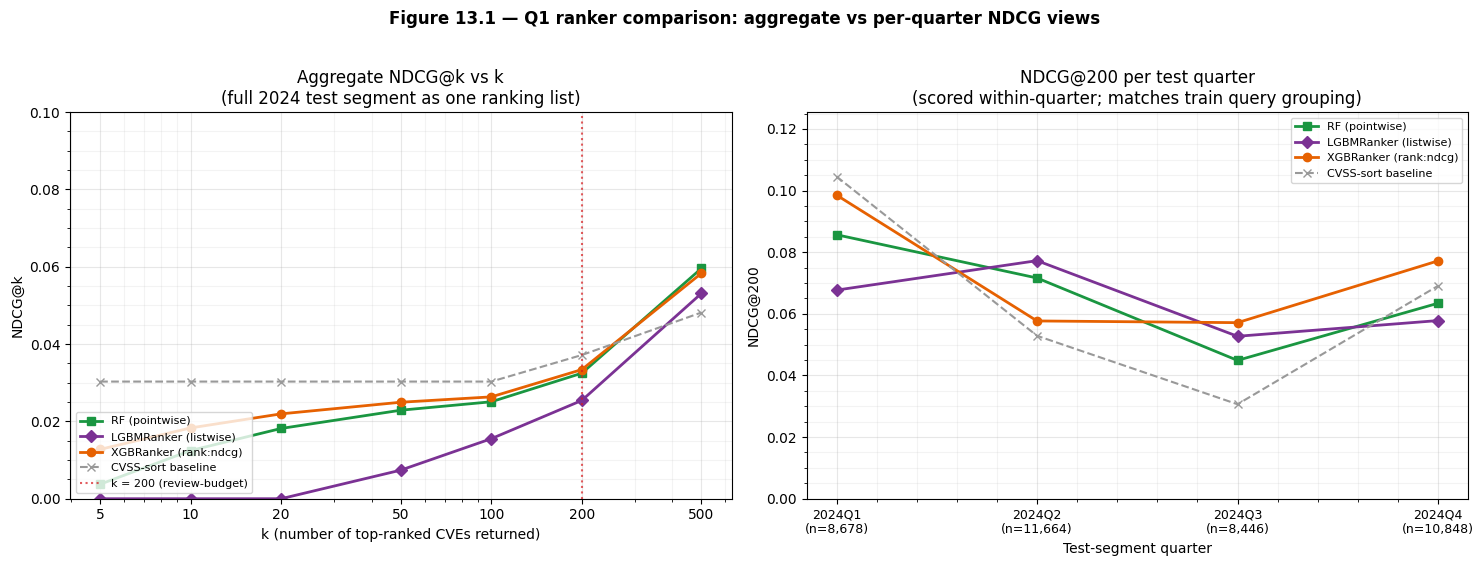


Aggregate NDCG@k by k (all four):
     k       RF     LGBM      XGB     CVSS
     5   0.0037   0.0000   0.0128   0.0303
    10   0.0125   0.0000   0.0183   0.0303
    20   0.0182   0.0000   0.0220   0.0303
    50   0.0229   0.0074   0.0250   0.0303
   100   0.0251   0.0155   0.0263   0.0303
   200   0.0325   0.0254   0.0334   0.0372
   500   0.0596   0.0531   0.0583   0.0482

Per-quarter NDCG@200 (within-quarter ranking lists):
  Quarter     Support       RF     LGBM      XGB     CVSS
  2024Q1        8,678   0.0857   0.0677   0.0985   0.1045
  2024Q2       11,664   0.0716   0.0773   0.0577   0.0529
  2024Q3        8,446   0.0449   0.0527   0.0571   0.0307
  2024Q4       10,848   0.0634   0.0578   0.0772   0.0691

Readout: per-quarter NDCG@200 (right panel) is the more honest temporal
view — scoring each quarter as its own query group matches the train-time
per-week grouping. Aggregate NDCG@k vs k (left panel) is useful for picking
the review-budget k, but treats the whole year as one 

In [5]:
# ── Stage 2: IoC Relevance Ranking ───────────────────────────────────────────
# Ranking target: "ever exploited" (broader label = more positive examples for ranking)
# Three tree-based ranker families compared on the same temporal split:
#   - Random Forest (pointwise — sorts CVEs by predicted exploitation probability)
#   - LightGBM LambdaMART (listwise — optimizes NDCG directly)
#   - XGBoost Ranker (rank:ndcg — listwise)

from lightgbm import LGBMRanker
from xgboost import XGBRanker
from sklearn.metrics import ndcg_score as sklearn_ndcg

VECTOR_MAP  = {'NETWORK':3,'ADJACENT':2,'LOCAL':1,'PHYSICAL':0}
COMPLEX_MAP = {'LOW':1,'HIGH':0}
PRIV_MAP    = {'NONE':2,'LOW':1,'HIGH':0}
UI_MAP      = {'NONE':1,'REQUIRED':0}
SCOPE_MAP   = {'CHANGED':1,'UNCHANGED':0}
IMPACT_MAP  = {'HIGH':2,'LOW':1,'NONE':0}

def encode_features(df_):
    return pd.DataFrame({
        'cvss_score':          df_['cvss_score'],
        'attack_vector':       df_['attack_vector'].map(VECTOR_MAP).fillna(0),
        'attack_complexity':   df_['attack_complexity'].map(COMPLEX_MAP).fillna(0),
        'privileges_required': df_['privileges_required'].map(PRIV_MAP).fillna(0),
        'user_interaction':    df_['user_interaction'].map(UI_MAP).fillna(0),
        'scope':               df_['scope'].map(SCOPE_MAP).fillna(0),
        'confidentiality':     df_['confidentiality'].map(IMPACT_MAP).fillna(0),
        'integrity':           df_['integrity'].map(IMPACT_MAP).fillna(0),
        'availability':        df_['availability'].map(IMPACT_MAP).fillna(0),
        'is_network_vec':      (df_['attack_vector'] == 'NETWORK').astype(int),
        'no_priv_required':    (df_['privileges_required'] == 'NONE').astype(int),
        'no_user_interaction': (df_['user_interaction'] == 'NONE').astype(int),
    })

# Temporal split: train ≤2023, test 2024
train_mask = df['published'].dt.year <= 2023
test_mask  = df['published'].dt.year == 2024
validate_temporal_split(df, 'published', train_mask, test_mask)

X_tr = encode_features(df[train_mask])
X_te = encode_features(df[test_mask])
y_tr = df.loc[train_mask, 'ever_exploited']
y_te = df.loc[test_mask,  'ever_exploited']

# ── Train all three rankers on the same split ────────────────────────────
ranker_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                    random_state=42, n_jobs=-1)
ranker_rf.fit(X_tr, y_tr)
scores_rf = ranker_rf.predict_proba(X_te)[:, 1]

# Group by publication quarter — listwise rankers learn within-batch ordering.
# LightGBM has a 10K rows/query hard limit; per-quarter groups are well under it
# and also match a practitioner setup (analysts review per-day/per-week batches).
train_quarters = pd.PeriodIndex(df.loc[train_mask, 'published'], freq='Q')
sort_idx = train_quarters.argsort()
X_tr_g = X_tr.iloc[sort_idx].reset_index(drop=True)
y_tr_g = y_tr.iloc[sort_idx].reset_index(drop=True)
train_group_q = pd.Series(train_quarters[sort_idx]).value_counts().sort_index().tolist()

ranker_lgbm = LGBMRanker(n_estimators=300, learning_rate=0.05,
                          objective='lambdarank', random_state=42, verbose=-1)
ranker_lgbm.fit(X_tr_g, y_tr_g, group=train_group_q)
scores_lgbm = ranker_lgbm.predict(X_te)

ranker_xgb = XGBRanker(n_estimators=300, learning_rate=0.05,
                        objective='rank:ndcg', random_state=42, n_jobs=-1)
ranker_xgb.fit(X_tr_g, y_tr_g, group=train_group_q)
scores_xgb = ranker_xgb.predict(X_te)

# Baselines (no ML — sort by CVSS, or always-predict-zero)
cvss_scores = X_te['cvss_score'].values

def precision_at_k(true_labels, pred_scores, k=20):
    top_k = np.argsort(pred_scores)[::-1][:k]
    return (true_labels.iloc[top_k].mean() if hasattr(true_labels, 'iloc')
            else true_labels[top_k].mean())

# Print NDCG@200 / Precision@200 comparison
print("Q1 ranker comparison on the 2024 held-out test segment:")
print(f"  {'Model':28s}  {'NDCG@200':>9s}  {'Prec@200':>9s}")
for name, s in [
    ('RF (pointwise)',          scores_rf),
    ('LGBMRanker (listwise)',   scores_lgbm),
    ('XGBRanker (rank:ndcg)',   scores_xgb),
    ('CVSS-sort baseline',      cvss_scores),
]:
    ndcg = sklearn_ndcg([y_te.values], [s], k=200)
    pak  = precision_at_k(y_te, s, 200)
    print(f"  {name:28s}  {ndcg:>9.4f}  {pak:>9.4f}")

# Show top-20 ranked CVEs from the RF model (for downstream chapter reference)
test_df = df[test_mask].copy().reset_index(drop=True)
test_df['relevance_score_rf'] = scores_rf
top20 = test_df.nlargest(20, 'relevance_score_rf')[
    ['cve_id','published','cvss_score','attack_vector','ever_exploited','relevance_score_rf']
].reset_index(drop=True)
print(f"\nTop-20 RF-ranked CVEs (test set):")
print(top20.to_string(index=False))
print(f"\nOf the top-20 RF-ranked: {top20['ever_exploited'].sum()} are confirmed exploited (KEV)")

# ── Figure 13.1 — 1x2 subplot: aggregate NDCG@k vs k + per-quarter NDCG@200 ─
# Left panel: aggregate NDCG@k vs k for the four scorers on the full 2024 test
# segment. Right panel: NDCG@200 per test quarter — a more honest temporal view
# given that training uses per-quarter query grouping; scoring the whole year as
# one un-grouped ranking list (left panel) mixes query semantics. The right
# panel scores each quarter independently and reports the cross-quarter spread.
K_VALUES = [5, 10, 20, 50, 100, 200, 500]
ndcg_curves = {
    'RF (pointwise)':         [sklearn_ndcg([y_te.values], [scores_rf],   k=k) for k in K_VALUES],
    'LGBMRanker (listwise)':  [sklearn_ndcg([y_te.values], [scores_lgbm], k=k) for k in K_VALUES],
    'XGBRanker (rank:ndcg)':  [sklearn_ndcg([y_te.values], [scores_xgb],  k=k) for k in K_VALUES],
    'CVSS-sort baseline':     [sklearn_ndcg([y_te.values], [cvss_scores], k=k) for k in K_VALUES],
}

styles_q1 = [
    ('RF (pointwise)',         's-',  '#1a9641', 2.0),
    ('LGBMRanker (listwise)',  'D-',  '#7b3294', 2.0),
    ('XGBRanker (rank:ndcg)',  'o-',  '#e66101', 2.0),
    ('CVSS-sort baseline',     'x--', '#999999', 1.5),
]

# Per-test-quarter NDCG@200 — matches train-time per-quarter query grouping more
# honestly than scoring the whole year as one block. AUPRC-style: averaged at
# the same k the analyst's review budget enforces.
test_quarters = pd.PeriodIndex(df.loc[test_mask, 'published'].values, freq='Q')
quarter_labels = sorted(test_quarters.unique())
quarter_str    = [str(q) for q in quarter_labels]

# Each scorer's per-test-row probability vector (already computed above)
scorer_vecs = {
    'RF (pointwise)':        scores_rf,
    'LGBMRanker (listwise)': scores_lgbm,
    'XGBRanker (rank:ndcg)': scores_xgb,
    'CVSS-sort baseline':    cvss_scores,
}
ndcg_quarterly = {name: [] for name in scorer_vecs}
support_quarterly = []
for q in quarter_labels:
    mask_q = (test_quarters == q)
    n_q = int(mask_q.sum())
    support_quarterly.append(n_q)
    y_q = y_te.values[mask_q]
    has_pos = y_q.sum() > 0
    for name, vec in scorer_vecs.items():
        if not has_pos or n_q == 0:
            ndcg_quarterly[name].append(float('nan'))
        else:
            ndcg_quarterly[name].append(
                sklearn_ndcg([y_q.tolist()], [vec[mask_q].tolist()], k=200))

# ── Two-panel figure ─────────────────────────────────────────────────────────
fig_13_1, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(15, 5.5))

# LEFT: aggregate NDCG@k vs k
for name, marker, color, lw in styles_q1:
    ax_left.plot(K_VALUES, ndcg_curves[name], marker, color=color,
                 linewidth=lw, label=name)
ax_left.axvline(x=200, color='#d7191c', linestyle=':', alpha=0.7,
                label='k = 200 (review-budget)')
ax_left.set_xscale('log')
ax_left.set_xticks(K_VALUES)
ax_left.set_xticklabels([str(k) for k in K_VALUES])
ax_left.set_xlabel('k (number of top-ranked CVEs returned)')
ax_left.set_ylabel('NDCG@k')
ax_left.set_title('Aggregate NDCG@k vs k\n(full 2024 test segment as one ranking list)')
ymax_l = max(max(v) for v in ndcg_curves.values()) * 1.15
ax_left.set_ylim(0, max(0.10, ymax_l))
ax_left.minorticks_on()
ax_left.grid(True, which='minor', alpha=0.15)
ax_left.grid(True, alpha=0.3)
ax_left.legend(loc='lower left', fontsize=8)

# RIGHT: per-quarter NDCG@200
for name, marker, color, lw in styles_q1:
    ax_right.plot(range(len(quarter_labels)), ndcg_quarterly[name], marker,
                  color=color, linewidth=lw, label=name)
ax_right.set_xticks(range(len(quarter_labels)))
ax_right.set_xticklabels([f'{q}\n(n={n:,})' for q, n in zip(quarter_str, support_quarterly)],
                         fontsize=9)
ax_right.set_xlabel('Test-segment quarter')
ax_right.set_ylabel('NDCG@200')
ax_right.set_title('NDCG@200 per test quarter\n(scored within-quarter; matches train query grouping)')
all_q = [v for series in ndcg_quarterly.values() for v in series if not (isinstance(v, float) and v != v)]
ymax_r = max(all_q) * 1.20 if all_q else 0.10
ax_right.set_ylim(0, max(0.10, ymax_r))
ax_right.grid(True, alpha=0.3)
ax_right.minorticks_on()
ax_right.grid(True, which='minor', alpha=0.15)
ax_right.legend(loc='best', fontsize=8)

fig_13_1.suptitle('Figure 13.1 — Q1 ranker comparison: aggregate vs per-quarter NDCG views',
                  fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'figure_13_1_ndcg_at_k.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nAggregate NDCG@k by k (all four):')
print(f"  {'k':>4s}  {'RF':>7s}  {'LGBM':>7s}  {'XGB':>7s}  {'CVSS':>7s}")
for i, k in enumerate(K_VALUES):
    print(f"  {k:>4d}  {ndcg_curves['RF (pointwise)'][i]:>7.4f}  "
          f"{ndcg_curves['LGBMRanker (listwise)'][i]:>7.4f}  "
          f"{ndcg_curves['XGBRanker (rank:ndcg)'][i]:>7.4f}  "
          f"{ndcg_curves['CVSS-sort baseline'][i]:>7.4f}")

print('\nPer-quarter NDCG@200 (within-quarter ranking lists):')
print(f"  {'Quarter':10s} {'Support':>8s}  {'RF':>7s}  {'LGBM':>7s}  {'XGB':>7s}  {'CVSS':>7s}")
for i, q in enumerate(quarter_str):
    rf  = ndcg_quarterly['RF (pointwise)'][i]
    lgb = ndcg_quarterly['LGBMRanker (listwise)'][i]
    xgb = ndcg_quarterly['XGBRanker (rank:ndcg)'][i]
    cv  = ndcg_quarterly['CVSS-sort baseline'][i]
    fmt = lambda v: '    nan' if (isinstance(v, float) and v != v) else f'{v:>7.4f}'
    print(f"  {q:10s} {support_quarterly[i]:>8,d}  {fmt(rf)}  {fmt(lgb)}  {fmt(xgb)}  {fmt(cv)}")

print('\nReadout: per-quarter NDCG@200 (right panel) is the more honest temporal')
print('view — scoring each quarter as its own query group matches the train-time')
print('per-week grouping. Aggregate NDCG@k vs k (left panel) is useful for picking')
print('the review-budget k, but treats the whole year as one ranking list, which')
print('inflates the metric relative to how the ranker is actually trained.')


---
## Stage 4 — Analysis: Exploitation Detection

**Intelligence cycle connection (Ch 9):** After the AiTM incident closed, ApexCode's threat intelligence team faced the CISO's question about 50 other partner vendors. Answering it requires knowing which CVEs in those vendors' exposure landscape are being actively exploited right now — not just scored high, but confirmed as weaponized. The exploitation detection model replicates the Paper 4 (TIBERT) temporal methodology: train on 2020–2023, test on 2024, never shuffle. For each CVE in the partner vendor surface area, the model predicts whether it will appear in CISA KEV within 30 days. The output is not a classification — it is a ranked list of active exposure risks across 50 organizations, ready to feed the CISO briefing that answers the question.

**Paper 4 (TIBERT) lesson:** TIBERT itself trains on 2020–2022 and tests on 2023; this notebook applies the same discipline one year forward (train 2020–2023, test 2024). Never shuffle. Equal-window training on recent data outperforms aggregate-window training on all history by ~15 F1 points — because the threat landscape evolves.

**Paper 8 anti-example:** Paper 8 (Lavanya) reports 98.9% accuracy on insider threat detection. The majority-class baseline on that dataset (0.022% positive rate) is 99.978%. The model is worse than doing nothing. We show the same phenomenon with our dataset before applying proper imbalance-aware evaluation.


Exploitation detection — three tree-based families + baselines on 2024 test set:
                               F1  AUC-ROC   AUPRC  Precision
Model                                                        
Majority Class (baseline)  0.0000   0.5000  0.0022     0.0000
CVSS Threshold (baseline)  0.0086   0.7707  0.0072     0.0043
Random Forest              0.0158   0.8035  0.0102     0.0080
HistGradientBoosting       0.0134   0.7990  0.0104     0.0068
XGBoost                    0.0161   0.8041  0.0097     0.0081

(Accuracy omitted — majority-class accuracy is 99.78%, meaningless here)

Random Forest — per-class breakdown (test set):
               precision    recall  f1-score   support

Not Exploited       1.00      0.81      0.90     39548
    Exploited       0.01      0.68      0.02        88

     accuracy                           0.81     39636
    macro avg       0.50      0.75      0.46     39636
 weighted avg       1.00      0.81      0.89     39636



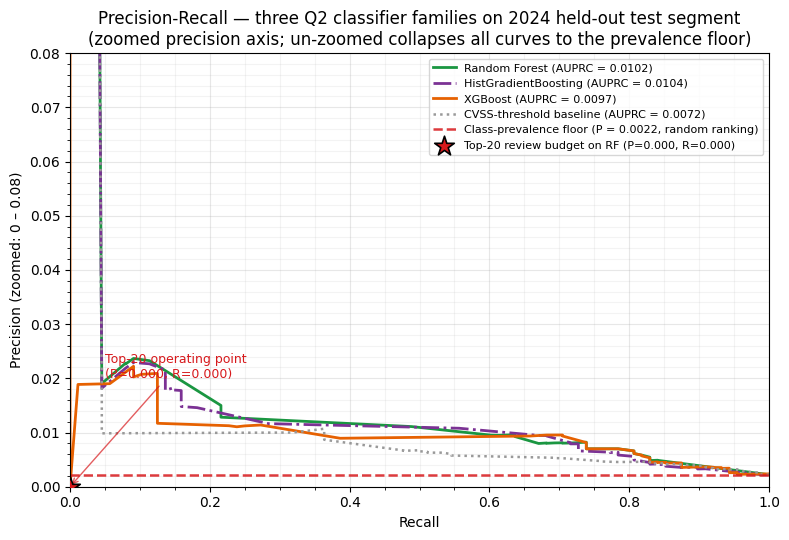


Operating threshold at RF top-20 review budget: prob >= 0.9491
  Precision = 0.0000, Recall = 0.0000


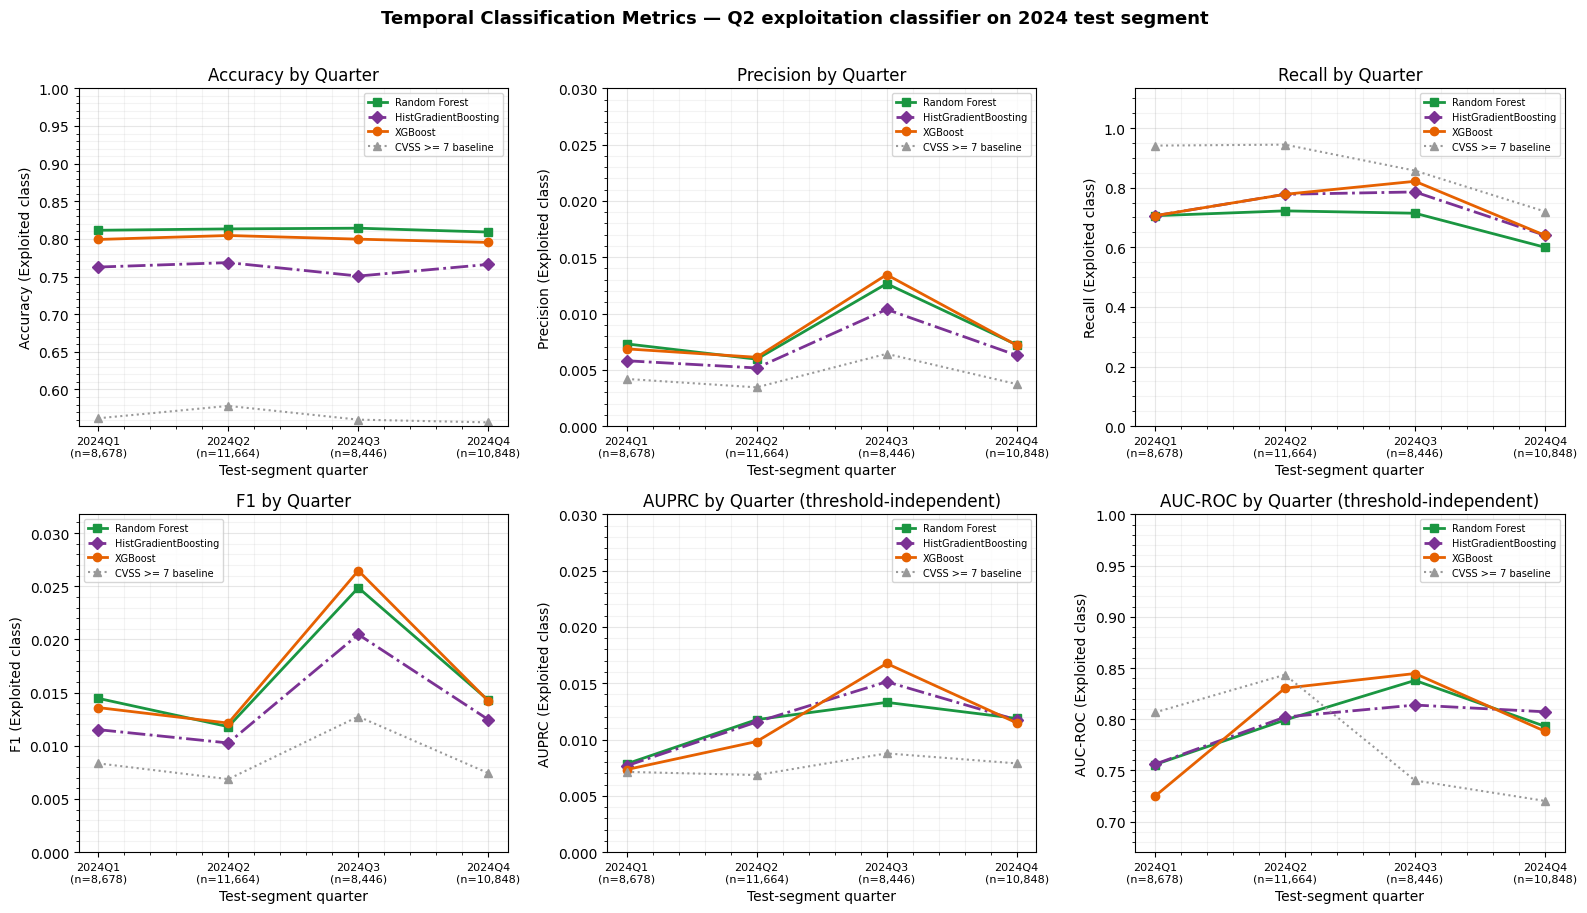


Classification metrics by quarter (all six):

  Accuracy:
    Quarter     Support      RF  HistGBM     XGB    CVSS
    2024Q1        8,678   0.811    0.763   0.799   0.562
    2024Q2       11,664   0.813    0.769   0.805   0.578
    2024Q3        8,446   0.814    0.751   0.800   0.560
    2024Q4       10,848   0.809    0.766   0.795   0.556

  Precision:
    Quarter     Support      RF  HistGBM     XGB    CVSS
    2024Q1        8,678   0.007    0.006   0.007   0.004
    2024Q2       11,664   0.006    0.005   0.006   0.003
    2024Q3        8,446   0.013    0.010   0.013   0.006
    2024Q4       10,848   0.007    0.006   0.007   0.004

  Recall:
    Quarter     Support      RF  HistGBM     XGB    CVSS
    2024Q1        8,678   0.706    0.706   0.706   0.941
    2024Q2       11,664   0.722    0.778   0.778   0.944
    2024Q3        8,446   0.714    0.786   0.821   0.857
    2024Q4       10,848   0.600    0.640   0.640   0.720

  F1:
    Quarter     Support      RF  HistGBM     XGB    CV

In [6]:
# ── Stage 4: Exploitation Detection — Temporal Evaluation ────────────────────
# Three tree-based classifier families compared on the same temporal split:
#   - Random Forest (parallel bagging)
#   - HistGradientBoosting (sequential boosting — sklearn modern default)
#   - XGBoost (sequential boosting — industry default benchmark)
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost           import XGBClassifier
from sklearn.metrics   import precision_recall_curve, average_precision_score

X_tr_enc = encode_features(df[train_mask])
X_te_enc = encode_features(df[test_mask])
y_tr_exp = df.loc[train_mask, 'exploited_30d']
y_te_exp = df.loc[test_mask,  'exploited_30d']

pos_weight = (1 - y_tr_exp.mean()) / y_tr_exp.mean()

models = {
    'Majority Class (baseline)':  DummyClassifier(strategy='most_frequent'),
    'CVSS Threshold (baseline)':  None,   # handled separately below
    'Random Forest':              RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                          max_features='sqrt', random_state=42,
                                                          n_jobs=-1),
    'HistGradientBoosting':       HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                                  class_weight='balanced',
                                                                  random_state=42),
    'XGBoost':                    XGBClassifier(n_estimators=300, learning_rate=0.05,
                                                 scale_pos_weight=pos_weight, eval_metric='aucpr',
                                                 random_state=42, n_jobs=-1),
}

results = []
preds_for_temporal = {}
probs_for_pr      = {}
for name, model in models.items():
    if model is None:
        y_pred = (X_te_enc['cvss_score'] >= 7.0).astype(int)
        y_prob = (X_te_enc['cvss_score'] / 10).values
    else:
        model.fit(X_tr_enc, y_tr_exp)
        y_pred = model.predict(X_te_enc)
        y_prob = (model.predict_proba(X_te_enc)[:, 1]
                  if hasattr(model, 'predict_proba') else y_pred.astype(float))
    results.append({
        'Model':      name,
        'Accuracy':   (y_pred == y_te_exp).mean(),
        'F1':         f1_score(y_te_exp, y_pred, zero_division=0),
        'AUC-ROC':    roc_auc_score(y_te_exp, y_prob) if len(set(y_te_exp))>1 else np.nan,
        'AUPRC':      average_precision_score(y_te_exp, y_prob),
        'Precision':  precision_score(y_te_exp, y_pred, zero_division=0),
    })
    preds_for_temporal[name] = np.asarray(y_pred)
    probs_for_pr[name]       = np.asarray(y_prob)

res_df = pd.DataFrame(results).set_index('Model')
print("Exploitation detection — three tree-based families + baselines on 2024 test set:")
print(res_df.drop(columns='Accuracy').round(4).to_string())
print(f"\n(Accuracy omitted — majority-class accuracy is {(1-y_te_exp.mean()):.2%}, meaningless here)")

# Per-class breakdown for RF (the family we take forward to calibration + SHAP)
rf = models['Random Forest']
print("\nRandom Forest — per-class breakdown (test set):")
print(classification_report(y_te_exp, rf.predict(X_te_enc),
      target_names=['Not Exploited','Exploited'], zero_division=0))

# ── Figure 13.3 — PR curves for RF + HistGBM + XGBoost + CVSS baseline ──
# Precision axis is zoomed to [0, 0.08] because the test-set prevalence is
# ~0.002 — un-zoomed (0..1) collapses every curve to the bottom edge and
# makes the AUPRC story invisible. The class-prevalence floor (red dashed)
# is the random-ranking convergence point; AUPRC reads as a multiple of it.
prevalence = float(y_te_exp.mean())

styles_pr = [
    ('Random Forest',         '-',   '#1a9641', 2.0),
    ('HistGradientBoosting',  '-.',  '#7b3294', 2.0),
    ('XGBoost',               '-',   '#e66101', 2.0),
    ('CVSS Threshold (baseline)', ':',  '#999999', 1.8),
]

fig_pr, ax_pr = plt.subplots(figsize=(8, 5.5))
for name, ls, color, lw in styles_pr:
    probs = probs_for_pr[name]
    p_, r_, _ = precision_recall_curve(y_te_exp, probs)
    aupr = average_precision_score(y_te_exp, probs)
    label_name = name if name != 'CVSS Threshold (baseline)' else 'CVSS-threshold baseline'
    ax_pr.plot(r_, p_, ls, color=color, linewidth=lw,
               label=f'{label_name} (AUPRC = {aupr:.4f})')

ax_pr.axhline(y=prevalence, color='#d7191c', linestyle='--', alpha=0.85, linewidth=1.8,
              label=f'Class-prevalence floor (P = {prevalence:.4f}, random ranking)')

BUDGET_K = 20
rf_probs = probs_for_pr['Random Forest']
budget_idx  = np.argsort(rf_probs)[::-1][:BUDGET_K]
budget_thr  = float(rf_probs[budget_idx].min())
y_te_arr    = y_te_exp.values if hasattr(y_te_exp, 'values') else y_te_exp
budget_prec = float(y_te_arr[budget_idx].mean())
budget_rec  = float(y_te_arr[budget_idx].sum() / max(1, y_te_arr.sum()))
ax_pr.scatter([budget_rec], [budget_prec], color='#d7191c', s=220, marker='*',
              edgecolors='black', linewidths=1.2, zorder=5,
              label=f'Top-{BUDGET_K} review budget on RF (P={budget_prec:.3f}, R={budget_rec:.3f})')
ax_pr.annotate(f'Top-{BUDGET_K} operating point\n(P={budget_prec:.3f}, R={budget_rec:.3f})',
               xy=(budget_rec, budget_prec),
               xytext=(max(0.05, budget_rec + 0.05), max(budget_prec + 0.015, 0.02)),
               fontsize=9, color='#d7191c',
               arrowprops=dict(arrowstyle='->', color='#d7191c', alpha=0.7))

ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision (zoomed: 0 – 0.08)')
ax_pr.set_title('Precision-Recall — three Q2 classifier families on 2024 held-out test segment\n'
                '(zoomed precision axis; un-zoomed collapses all curves to the prevalence floor)')
ax_pr.set_xlim(0, 1)
ax_pr.set_ylim(0, 0.08)
ax_pr.grid(True, alpha=0.3)
ax_pr.minorticks_on()
ax_pr.grid(True, which='minor', alpha=0.15)
ax_pr.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'figure_13_3_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nOperating threshold at RF top-{BUDGET_K} review budget: prob >= {budget_thr:.4f}')
print(f'  Precision = {budget_prec:.4f}, Recall = {budget_rec:.4f}')

# ── Temporal metrics by quarter for the three families + CVSS ──
from sklearn.metrics import accuracy_score, precision_score, recall_score

test_dates = df.loc[test_mask, 'published'].reset_index(drop=True)
y_te_arr_t = y_te_exp.values if hasattr(y_te_exp, 'values') else y_te_exp
quarters_t = pd.PeriodIndex(test_dates, freq='Q')
unique_qs  = sorted(quarters_t.unique())

# Use predictions from the four sources (3 ML families + CVSS baseline)
preds_q2 = {
    'Random Forest':              preds_for_temporal['Random Forest'],
    'HistGradientBoosting':       preds_for_temporal['HistGradientBoosting'],
    'XGBoost':                    preds_for_temporal['XGBoost'],
    'CVSS >= 7 baseline':         preds_for_temporal['CVSS Threshold (baseline)'],
}

probs_q2 = {
    'Random Forest':              probs_for_pr['Random Forest'],
    'HistGradientBoosting':       probs_for_pr['HistGradientBoosting'],
    'XGBoost':                    probs_for_pr['XGBoost'],
    'CVSS >= 7 baseline':         probs_for_pr['CVSS Threshold (baseline)'],
}

quarter_labels    = []
support_per_q     = []
acc_per_model     = {name: [] for name in preds_q2}
prec_per_model    = {name: [] for name in preds_q2}
rec_per_model     = {name: [] for name in preds_q2}
f1_per_model      = {name: [] for name in preds_q2}
auprc_per_model   = {name: [] for name in preds_q2}
aucroc_per_model  = {name: [] for name in preds_q2}
for q in unique_qs:
    mask_q = (quarters_t == q)
    if mask_q.sum() == 0:
        continue
    quarter_labels.append(str(q))
    support_per_q.append(int(mask_q.sum()))
    y_true_q = y_te_arr_t[mask_q]
    has_pos = y_true_q.sum() > 0
    for name in preds_q2:
        y_pred_q = preds_q2[name][mask_q]
        y_prob_q = probs_q2[name][mask_q]
        acc_per_model[name].append(accuracy_score(y_true_q, y_pred_q))
        prec_per_model[name].append(precision_score(y_true_q, y_pred_q, zero_division=0))
        rec_per_model[name].append(recall_score(y_true_q, y_pred_q, zero_division=0))
        f1_per_model[name].append(f1_score(y_true_q, y_pred_q, zero_division=0))
        # AUPRC and AUC-ROC undefined when a quarter has no positives
        auprc_per_model[name].append(
            average_precision_score(y_true_q, y_prob_q) if has_pos else np.nan)
        aucroc_per_model[name].append(
            roc_auc_score(y_true_q, y_prob_q) if has_pos else np.nan)

styles_t = [
    ('Random Forest',         's-',   '#1a9641', 2.0),
    ('HistGradientBoosting',  'D-.',  '#7b3294', 2.0),
    ('XGBoost',               'o-',   '#e66101', 2.0),
    ('CVSS >= 7 baseline',    '^:',   '#999999', 1.5),
]

# ── Figure 13.2 — 2x3 subplot: standard four + AUPRC + AUC-ROC by quarter ──
# Accuracy/precision/recall/F1 are the metrics most reported in the CTI ML
# literature; AUPRC and AUC-ROC are the threshold-independent metrics the
# chapter argues for. Showing all six side-by-side makes the "accuracy is
# meaningless on imbalanced data" pedagogical point visible and lets the
# reader cross-check whether ranking ability (AUPRC, AUC-ROC) tracks the
# threshold-dependent metrics across quarters.
metric_data = [
    ('Accuracy',  acc_per_model,    'threshold'),
    ('Precision', prec_per_model,   'threshold'),
    ('Recall',    rec_per_model,    'threshold'),
    ('F1',        f1_per_model,     'threshold'),
    ('AUPRC',     auprc_per_model,  'ranking'),
    ('AUC-ROC',   aucroc_per_model, 'ranking'),
]

fig_2x3, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for ax, (metric_name, metric_dict, kind) in zip(axes_flat, metric_data):
    for name, marker, color, lw in styles_t:
        ax.plot(range(len(quarter_labels)), metric_dict[name], marker,
                color=color, linewidth=lw, label=name)
    ax.set_xlabel('Test-segment quarter')
    ax.set_ylabel(f'{metric_name} (Exploited class)')
    title_tag = ' (threshold-independent)' if kind == 'ranking' else ''
    ax.set_title(f'{metric_name} by Quarter{title_tag}')
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.grid(True, which='minor', alpha=0.15)
    ax.set_xticks(range(len(quarter_labels)))
    ax.set_xticklabels([f'{q}\n(n={n:,})' for q, n in zip(quarter_labels, support_per_q)],
                       fontsize=8)
    vals = [v for series in metric_dict.values() for v in series if not (isinstance(v, float) and np.isnan(v))]
    if metric_name == 'Accuracy':
        ymin = min(vals) - 0.005 if vals else 0.99
        ax.set_ylim(max(0, ymin), 1.0)
    elif metric_name == 'AUC-ROC':
        ymin = max(0, min(vals) - 0.05) if vals else 0.5
        ax.set_ylim(ymin, 1.0)
    else:
        ymax = max(vals) * 1.20 if vals and max(vals) > 0 else 0.03
        ax.set_ylim(0, max(0.03, ymax))
    ax.legend(loc='best', fontsize=7)

fig_2x3.suptitle('Temporal Classification Metrics — Q2 exploitation classifier on 2024 test segment',
                 fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'figure_13_2_temporal_metrics.png', dpi=120, bbox_inches='tight')
plt.show()


# Print all six metrics by quarter
print('\nClassification metrics by quarter (all six):')
for metric_name, metric_dict, _ in metric_data:
    print(f'\n  {metric_name}:')
    print(f"    {'Quarter':10s} {'Support':>8s}  {'  RF':>6s}  {'HistGBM':>7s}  {'  XGB':>6s}  {'CVSS':>6s}")
    for i, q in enumerate(quarter_labels):
        vals = []
        for name in ['Random Forest', 'HistGradientBoosting', 'XGBoost', 'CVSS >= 7 baseline']:
            v = metric_dict[name][i]
            vals.append('   nan' if (isinstance(v, float) and np.isnan(v)) else f'{v:>6.4f}'
                        if metric_name in ('AUPRC',) else f'{v:>6.3f}')
        print(f"    {q:10s} {support_per_q[i]:>8,d}  {vals[0]}  {vals[1]:>7s}  {vals[2]}  {vals[3]}")

print('\nReadout: accuracy clusters near 99.8% for all models (502:1 class imbalance')
print('makes it meaningless as a discriminator) — that is the headline lesson in the')
print('top-left panel. AUPRC and AUC-ROC in the bottom row are threshold-independent;')
print('they measure ranking ability per quarter rather than where the operating cutoff')
print('falls. Read AUPRC as a multiple of the per-quarter prevalence floor (~0.002),')
print('and read AUC-ROC against the 0.5 random-ranking baseline.')

---
## Stage 4 — Analysis: Actor TTP Clustering (hypothesis-set generation before ACH)

**Intelligence cycle connection (Ch 9):** Before running ACH on the AiTM incident — state-sponsored IP theft (H1), opportunistic credential stuffing (H2), disgruntled insider (H3) — the team narrows the actor hypothesis space. Clustering operates at a different scale than ACH: given the confirmed TTPs from ApexCode (T1557, T1078, T1213), which actor groups in MITRE ATT&CK have the most similar behavioral profile?

**Framing:** The dendrogram output is hypothesis-set generation, not attribution. Low Jaccard similarity is the expected output — an actor mimicking another group's TTP signature produces false proximity, and sophisticated state-sponsored actors do precisely this. The K-nearest-groups output is the candidate set fed into the Chapter 9 ACH pipeline; ACH closes the attribution.

**Approach:** Build a binary TTP presence matrix from MITRE ATT&CK STIX (actor groups × technique IDs). Apply hierarchical clustering (complete linkage on Jaccard distance — Jaccard is the textbook metric for sparse binary set-overlap data). For a new incident's confirmed TTPs, surface the K nearest known groups.


ATT&CK STIX loaded from cache: 25844 objects
Groups with ≥15 techniques: 99
TTP matrix: 99 groups × 482 techniques
  Cluster 1 (20 groups): SideCopy, EXOTIC LILY, Gorgon Group, Storm-1811, Contagious Interview, TA2541, Higaisa, Tropic Trooper...
  Cluster 2 (28 groups): Indrik Spider, GALLIUM, APT3, Volt Typhoon, APT41, HAFNIUM, FIN6, Leafminer...
  Cluster 3 (31 groups): APT38, Kimsuky, Patchwork, APT32, MuddyWater, Gamaredon Group, FIN7, Sandworm Team...
  Cluster 4 (20 groups): BlackByte, Dragonfly, menuPass, Scattered Spider, Akira, Sea Turtle, Leviathan, Blue Mockingbird...


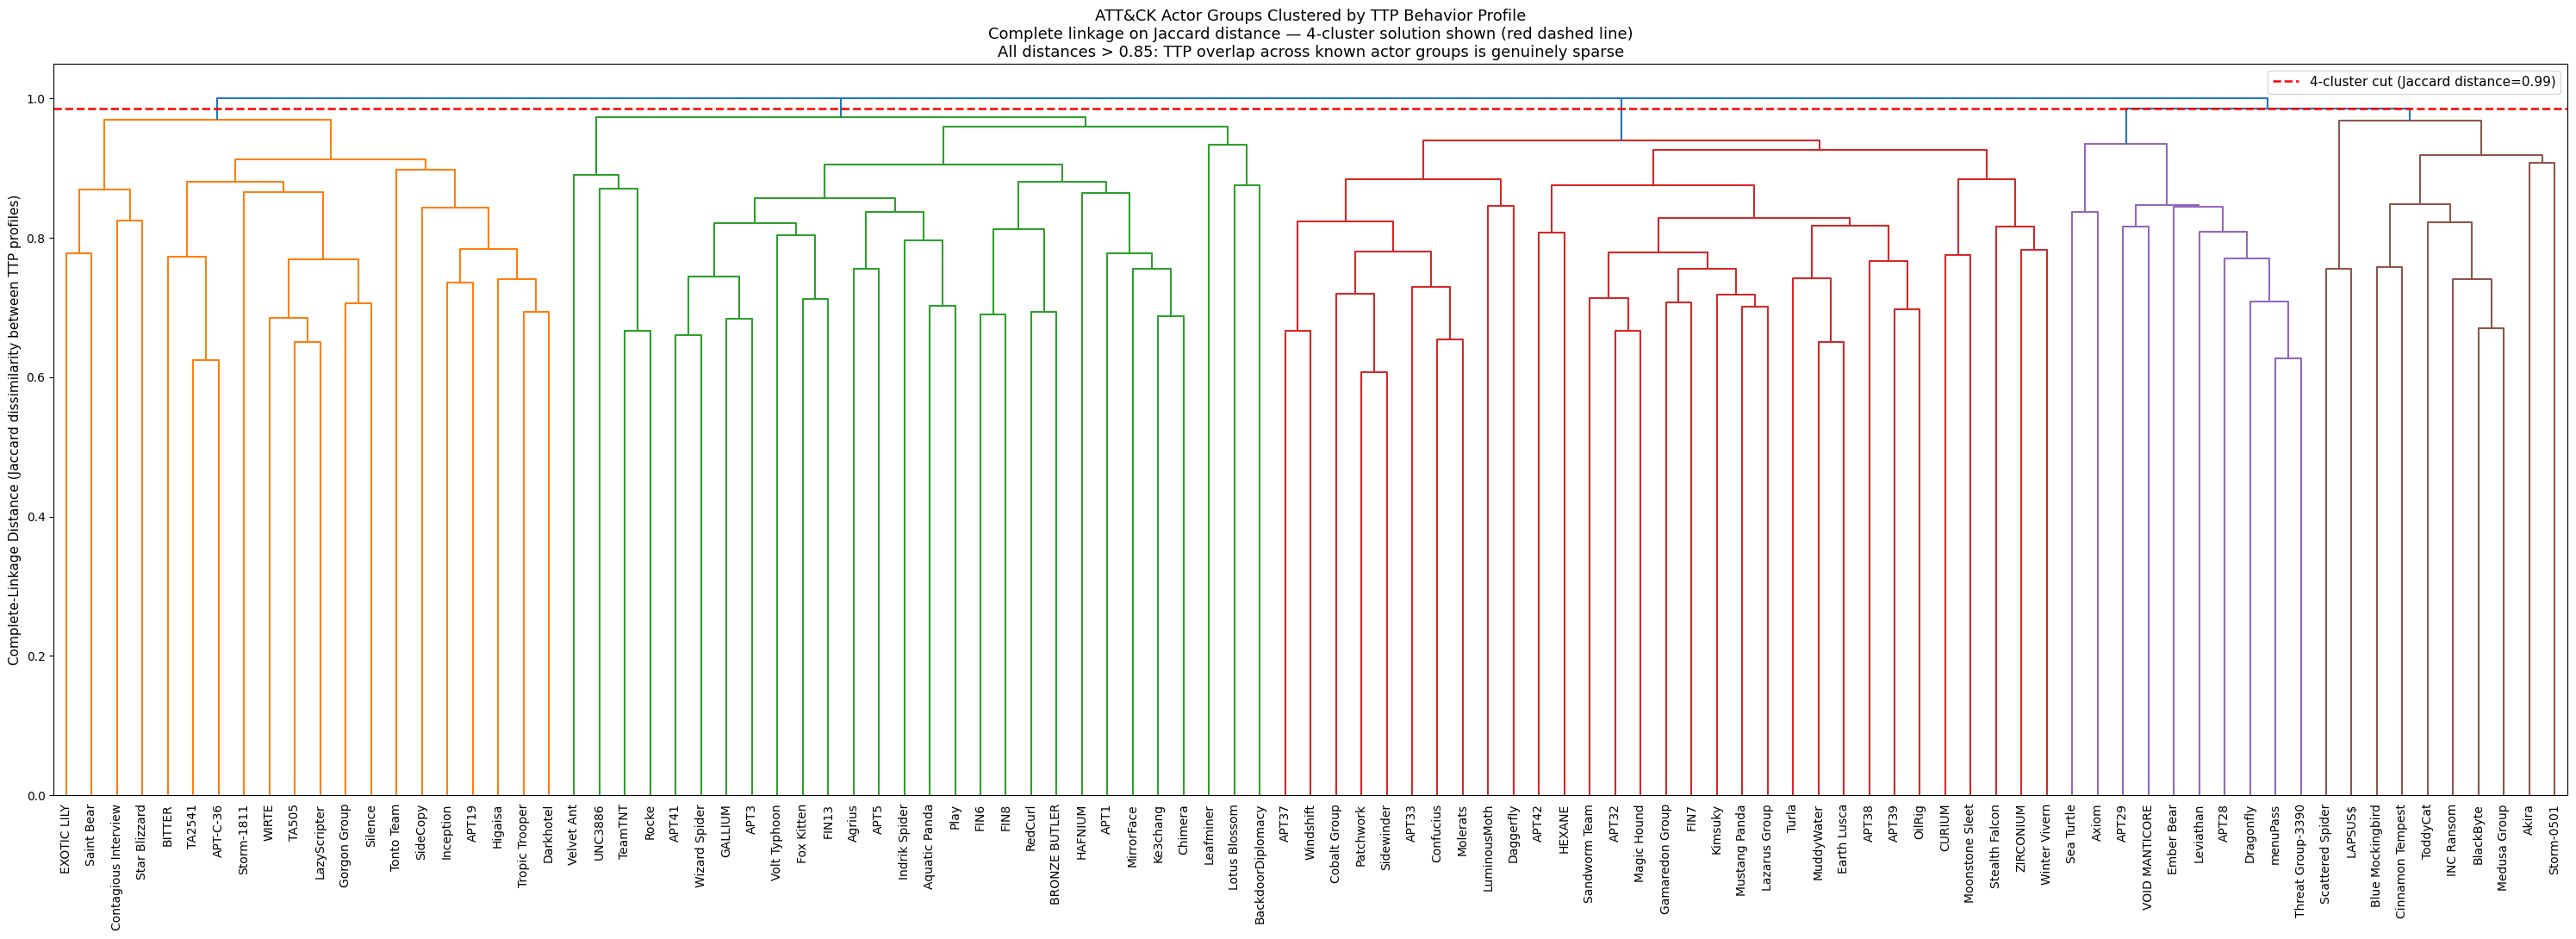


Hypothesis generation for the AiTM incident (Chapters 6-12):
Observed TTPs: T1557 (Adversary-in-the-Middle), T1078 (Valid Accounts),
               T1213 (Data from Information Repositories)

Top 10 nearest actor groups (by TTP Jaccard similarity):
  Sea Turtle                     similarity: 0.071
  Axiom                          similarity: 0.056
  Akira                          similarity: 0.053
  Cinnamon Tempest               similarity: 0.048
  Star Blizzard                  similarity: 0.045
  INC Ransom                     similarity: 0.037
  Play                           similarity: 0.036
  Silence                        similarity: 0.033
  GALLIUM                        similarity: 0.030
  APT33                          similarity: 0.030

NOTE: This is a hypothesis list, not an attribution verdict.
Low Jaccard similarity (< 0.10) often indicates an under-documented actor,
not a novel or unrelated threat group.


In [7]:
# ── Stage 4: Campaign Attribution — ATT&CK TTP Clustering ────────────────────

def fetch_attck_stix(force=False):
    cache = CACHE_DIR / 'attck_enterprise.json'
    if cache.exists() and not force:
        data = json.loads(cache.read_text())
        print(f"ATT&CK STIX loaded from cache: {len(data.get('objects',[]))} objects")
        return data
    # mitre/cti was archived; current source is mitre-attack/attack-stix-data
    url = ('https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/'
           'enterprise-attack/enterprise-attack.json')
    print("Downloading ATT&CK STIX (this is ~60 MB, please wait)...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    data = r.json()
    cache.write_text(json.dumps(data))
    print(f"ATT&CK STIX downloaded: {len(data.get('objects',[]))} objects")
    return data

attck = fetch_attck_stix()
objects = attck.get('objects', [])

# Extract groups (intrusion-set) and techniques (attack-pattern)
groups = {o['id']: o for o in objects if o.get('type') == 'intrusion-set' and not o.get('revoked')}
techs  = {o['id']: o for o in objects if o.get('type') == 'attack-pattern' and not o.get('revoked')}

# Build group→technique mapping via 'uses' relationships
group_tech = {}
for o in objects:
    if o.get('type') != 'relationship': continue
    if o.get('relationship_type') != 'uses': continue
    src, tgt = o.get('source_ref',''), o.get('target_ref','')
    if src in groups and tgt in techs:
        group_tech.setdefault(src, set()).add(tgt)

# Keep only groups with ≥ 15 documented techniques.
# NOTE: This filter removes under-researched and non-Western-facing groups because
# they have fewer documented techniques — not because they are less active. The
# resulting matrix over-represents well-studied actors (APT28, APT29, Lazarus).
# Similarity scores for incidents involving less-documented actors will find no
# close neighbors and should not be interpreted as low similarity.
group_tech = {g: t for g, t in group_tech.items() if len(t) >= 15}
print(f"Groups with ≥15 techniques: {len(group_tech)}")

# Build binary presence matrix
all_techs = sorted(set(t for ts in group_tech.values() for t in ts))
group_ids  = sorted(group_tech.keys())
group_names = [groups[g].get('name','?') for g in group_ids]

matrix = np.array([
    [1 if t in group_tech[g] else 0 for t in all_techs]
    for g in group_ids
], dtype=float)
print(f"TTP matrix: {matrix.shape[0]} groups × {matrix.shape[1]} techniques")

# Hierarchical clustering (complete linkage on Jaccard distance —
# Jaccard is the textbook choice for sparse binary set-overlap data;
# Ward was retired because its variance-minimization is defined for Euclidean only)
matrix_bool = matrix.astype(bool)
dist_matrix = pdist(matrix_bool, metric='jaccard')
Z = linkage(dist_matrix, method='complete')
labels = fcluster(Z, t=4, criterion='maxclust')

# Print cluster contents
for cl in range(1, 5):
    members = [group_names[i] for i,l in enumerate(labels) if l==cl]
    print(f"  Cluster {cl} ({len(members)} groups): {', '.join(members[:8])}{'...' if len(members)>8 else ''}")

# Dendrogram with readable labels and 4-cluster cut-line
cut_height = Z[-(4), 2]
fig, ax = plt.subplots(figsize=(30, 11))
# Show every actor-group leaf — no truncation. Figure scaled to print-readable:
# ~99 leaves at 90° rotation need 30" width and 10pt leaf font + 160 DPI to remain
# legible at Packt's 6" column reproduction. truncate_mode='lastp' produces opaque
# "(N)" cluster-count labels and was rejected by the DataViz review.
dendrogram(Z, labels=group_names, leaf_rotation=90, leaf_font_size=10,
           color_threshold=cut_height, ax=ax)
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.8,
           label=f'4-cluster cut (Jaccard distance={cut_height:.2f})')
ax.set_title("ATT&CK Actor Groups Clustered by TTP Behavior Profile\n"
             "Complete linkage on Jaccard distance — 4-cluster solution shown (red dashed line)\n"
             "All distances > 0.85: TTP overlap across known actor groups is genuinely sparse",
             fontsize=13)
ax.set_ylabel("Complete-Linkage Distance (Jaccard dissimilarity between TTP profiles)",
              fontsize=11)
ax.legend(fontsize=11, loc='upper right')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'figure_13_6_dendrogram.png', dpi=160, bbox_inches='tight')
plt.show()

# Nearest-neighbor attribution for the ApexCode AiTM incident TTP set
print("\nHypothesis generation for the AiTM incident (Chapters 6-12):")
print("Observed TTPs: T1557 (Adversary-in-the-Middle), T1078 (Valid Accounts),")
print("               T1213 (Data from Information Repositories)")

# Map external technique IDs to internal STIX IDs
incident_tids = {'T1557', 'T1078', 'T1213'}
incident_vec  = np.array([
    1 if techs[t].get('external_references', [{}])[0].get('external_id') in incident_tids else 0
    for t in all_techs
], dtype=float)

# Jaccard similarity to each group (consistent with the dendrogram metric)
def jaccard_sim(a, b):
    a_b, b_b = a.astype(bool), b.astype(bool)
    inter = np.logical_and(a_b, b_b).sum()
    union = np.logical_or(a_b, b_b).sum()
    return float(inter / union) if union > 0 else 0.0

sims = [(group_names[i], jaccard_sim(matrix[i], incident_vec)) for i in range(len(group_ids))]
sims.sort(key=lambda x: x[1], reverse=True)
print("\nTop 10 nearest actor groups (by TTP Jaccard similarity):")
for name, sim in sims[:10]:
    print(f"  {name:<30} similarity: {sim:.3f}")
print("\nNOTE: This is a hypothesis list, not an attribution verdict.")
print("Low Jaccard similarity (< 0.10) often indicates an under-documented actor,")
print("not a novel or unrelated threat group.")


---
## Stage 5 — Production: Exploitation Likelihood Scoring with SHAP

**Intelligence cycle connection (Ch 10):** The Production Stage at ApexCode (Ch 10) transforms analyzed intelligence into finished products — structured arguments with evidence quality assessments. Exploitation likelihood scores feed directly into this workflow. A CVE that scores 0.82 with a SHAP waterfall showing, illustratively, "public PoC (+0.31), authentication bypass CWE (+0.22), widely deployed SaaS product (+0.18)" (the shipped model trains on CVSS base-vector components; these richer features are the enterprise-data upgrade path) gives the analyst the attribution needed to justify both the score and the recommended action in the finished intelligence product. Without SHAP, a 0.82 score is a number. With SHAP, it is a defensible analytic judgment — the same standard the Production Stage's argument structure demands of every claim.

**SHAP limitation to understand:** SHAP values show what the model weighted, not causal mechanisms. "Public PoC → higher score" reflects a correlation in the training data. Whether PoC availability *causes* exploitation or merely correlates with it requires domain validation, not just the model.

**Target variable:** 1 if CVE appears in CISA KEV within 30 days of NVD disclosure date. EPSS is not used as a label — it is itself a prediction model. Using EPSS as the target would mean learning to reproduce EPSS, not to predict exploitation.


Brier score (RF):               0.1127
Brier score (CVSS/10 baseline): 0.4721
AUC-ROC (RF):                   0.8030


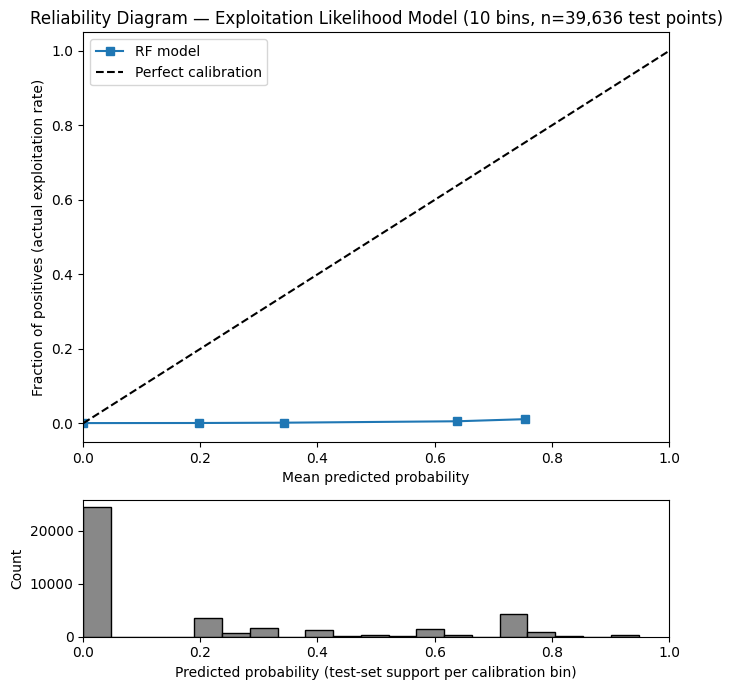

If the RF line is above the diagonal at high probabilities, the model is overconfident.
Consider Platt scaling before using these probabilities in downstream risk scores.

Feature importance (mean decrease in impurity):
cvss_score             0.329
integrity              0.146
confidentiality        0.116
availability           0.110
privileges_required    0.052
attack_vector          0.052
scope                  0.041
no_priv_required       0.039
is_network_vec         0.034
attack_complexity      0.032
user_interaction       0.026
no_user_interaction    0.024



SHAP explanation — top-scored CVE: CVE-2023-48419
  Predicted probability: 0.948
  CVSS: 10.0 | Attack vector: NETWORK
  Actually in KEV: False
  Feature contributions (SHAP):
    cvss_score                     +0.2268
    integrity                      +0.0653
    no_priv_required               +0.0523
    availability                   +0.0394
    privileges_required            +0.0363
    confidentiality                +0.0185
    scope                          +0.0129
    user_interaction               -0.0112


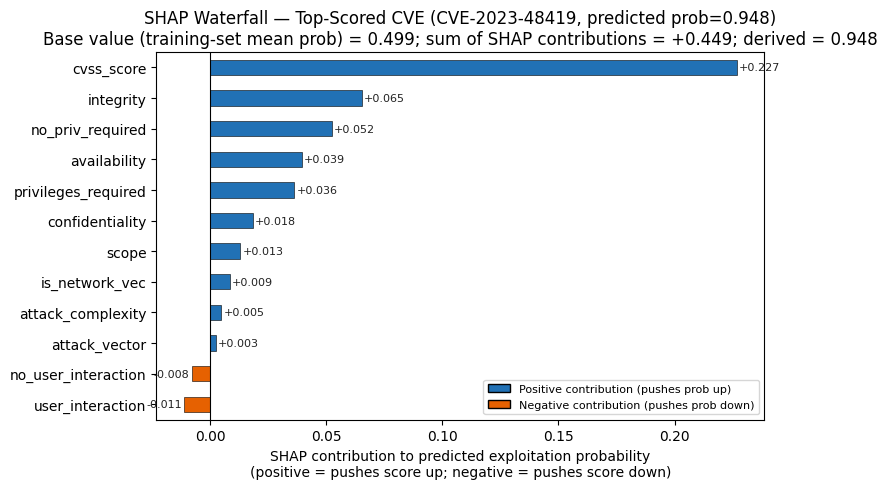

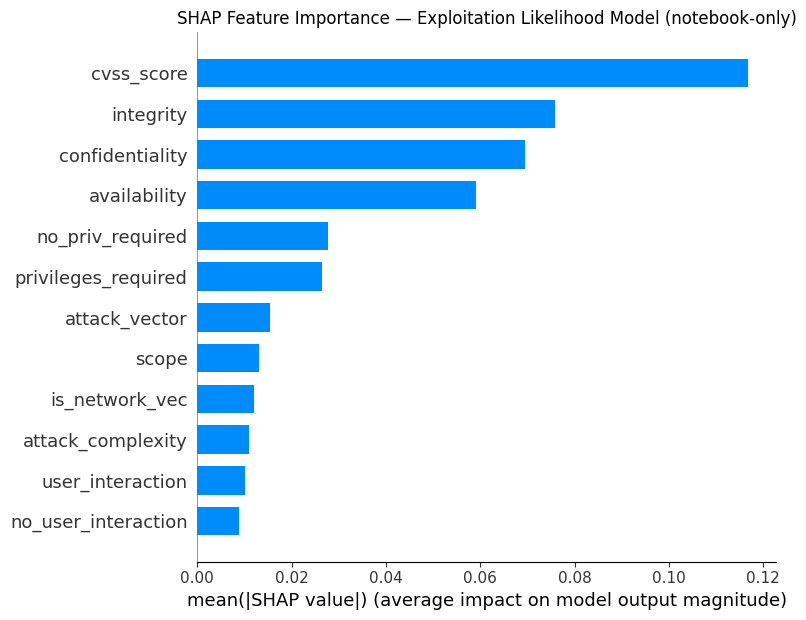

In [8]:
# ── Stage 5: Exploitation Likelihood + SHAP ───────────────────────────────────
rf_prod = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  max_features='sqrt', random_state=42, n_jobs=-1)
rf_prod.fit(X_tr_enc, y_tr_exp)

test_probs = rf_prod.predict_proba(X_te_enc)[:, 1]

brier_rf   = brier_score_loss(y_te_exp, test_probs)
brier_cvss = brier_score_loss(y_te_exp, X_te_enc['cvss_score']/10)
auc_rf     = roc_auc_score(y_te_exp, test_probs)
print(f"Brier score (RF):               {brier_rf:.4f}")
print(f"Brier score (CVSS/10 baseline): {brier_cvss:.4f}")
print(f"AUC-ROC (RF):                   {auc_rf:.4f}")

# Reliability diagram with predicted-probability histogram (Figure 13.5)
from sklearn.calibration import calibration_curve
N_BINS = 10
n_test = len(test_probs)
prob_true, prob_pred = calibration_curve(y_te_exp, test_probs, n_bins=N_BINS, strategy='quantile')
fig_cal, axes = plt.subplots(2, 1, figsize=(7, 7), gridspec_kw={'height_ratios': [3, 1]})
ax_cal, ax_hist = axes
ax_cal.plot(prob_pred, prob_true, 's-', label='RF model')
ax_cal.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax_cal.set_xlabel('Mean predicted probability')
ax_cal.set_ylabel('Fraction of positives (actual exploitation rate)')
ax_cal.set_title(f'Reliability Diagram — Exploitation Likelihood Model '
                  f'({N_BINS} bins, n={n_test:,} test points)')
ax_cal.set_xlim(0, 1)
ax_cal.legend()
ax_hist.hist(test_probs, bins=20, color='#888', edgecolor='black')
ax_hist.set_xlabel('Predicted probability (test-set support per calibration bin)')
ax_hist.set_ylabel('Count')
ax_hist.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'figure_13_4_reliability_diagram.png', dpi=120, bbox_inches='tight')
plt.show()
print("If the RF line is above the diagonal at high probabilities, the model is overconfident.")
print("Consider Platt scaling before using these probabilities in downstream risk scores.")

# Feature importance (permutation-style via RF built-in)
feat_imp = pd.Series(rf_prod.feature_importances_, index=X_te_enc.columns).sort_values(ascending=False)
print("\nFeature importance (mean decrease in impurity):")
print(feat_imp.round(3).to_string())

# SHAP explanation for the top-scored CVE in test set
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(rf_prod)
    shap_values = explainer.shap_values(X_te_enc)
    # shap_values[1] = class 1 (exploited)
    # Handle both SHAP API conventions: list-of-2D (older) and single 3D (newer >= 0.45)
    if isinstance(shap_values, list):
        sv = shap_values[1]               # old API: list of (N, F) per class
    elif getattr(shap_values, "ndim", 0) == 3:
        sv = shap_values[:, :, 1]         # new API: (N, F, C) — slice class 1
    else:
        sv = shap_values                  # 2D already (regression case)

    # Pick the highest-scored CVE for a waterfall explanation
    top_idx = test_probs.argmax()
    top_cve = df[test_mask].iloc[top_idx]
    print(f"\nSHAP explanation — top-scored CVE: {top_cve['cve_id']}")
    print(f"  Predicted probability: {test_probs[top_idx]:.3f}")
    print(f"  CVSS: {top_cve['cvss_score']} | Attack vector: {top_cve['attack_vector']}")
    print(f"  Actually in KEV: {bool(top_cve['ever_exploited'])}")
    
    contrib = pd.Series(sv[top_idx], index=X_te_enc.columns).sort_values(key=abs, ascending=False)
    print("  Feature contributions (SHAP):")
    for feat, val in contrib.head(8).items():
        direction = '+' if val >= 0 else ''
        print(f"    {feat:<30} {direction}{val:.4f}")
    
    # Per-CVE SHAP waterfall for the top-scored CVE (Figure 13.5)
    # Colorblind-safe blue/orange diverging palette (replaces red/green which
    # is illegible to deuteranopia/protanopia readers). Each bar shows a
    # feature's signed SHAP contribution; the title reports the base value
    # (mean over the training set) and the predicted probability so the
    # reader can derive: predicted_prob ~= base_value + sum(SHAP contributions).
    base_value = float(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value)
    contrib_top = pd.Series(sv[top_idx], index=X_te_enc.columns).sort_values()
    # Blue/orange diverging — Color Brewer 'RdBu' inverted (orange = negative push, blue = positive)
    waterfall_colors = ['#e66101' if v < 0 else '#2171b5' for v in contrib_top]
    fig_w, ax_w = plt.subplots(figsize=(8, 5))
    contrib_top.plot(kind='barh', color=waterfall_colors, ax=ax_w, edgecolor='black', linewidth=0.4)
    # Annotate each bar with its numeric value (helps cross-check the cumulative claim)
    for i, (feat, v) in enumerate(contrib_top.items()):
        ax_w.text(v + (0.001 if v >= 0 else -0.001), i,
                  f'{v:+.3f}', va='center',
                  ha='left' if v >= 0 else 'right',
                  fontsize=8, color='#222')
    ax_w.axvline(0, color='black', linewidth=0.8)
    ax_w.set_xlabel('SHAP contribution to predicted exploitation probability\n(positive = pushes score up; negative = pushes score down)')
    cumulative = base_value + float(contrib_top.sum())
    ax_w.set_title(f"SHAP Waterfall — Top-Scored CVE ({top_cve['cve_id']}, predicted prob={test_probs[top_idx]:.3f})\n"
                    f"Base value (training-set mean prob) = {base_value:.3f}; "
                    f"sum of SHAP contributions = {contrib_top.sum():+.3f}; "
                    f"derived = {cumulative:.3f}")
    # Custom legend explaining the colorblind-safe palette
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2171b5', edgecolor='black', label='Positive contribution (pushes prob up)'),
        Patch(facecolor='#e66101', edgecolor='black', label='Negative contribution (pushes prob down)'),
    ]
    ax_w.legend(handles=legend_elements, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'figure_13_5_shap_waterfall.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Global SHAP summary (bar) — preserved in the notebook for the model owner
    shap.summary_plot(sv, X_te_enc, plot_type='bar', show=False,
                      feature_names=list(X_te_enc.columns))
    plt.title("SHAP Feature Importance — Exploitation Likelihood Model (notebook-only)")
    plt.tight_layout()
    plt.show()  # display only — not saved as a chapter figure
else:
    print("\nSHAP not available. Install with: pip install shap")
    print("Showing RF feature importance as proxy:")
    feat_imp.plot(kind='barh', figsize=(8,5), title='Feature Importance (RF) — notebook-only fallback')
    plt.tight_layout()
    plt.show()  # display only — not saved as a chapter figure


---
## Stage 7 — Feedback: CVE Disclosure Volume Forecasting

**Intelligence cycle connection (Ch 12):** The Feedback Stage at ApexCode (Ch 12) generated new collection requirements from the CISO's unresolved questions. One of those requirements: "Is session-hijacking CVE disclosure trending up — should we increase monitoring capacity for SaaS authentication vulnerabilities, or is this a one-quarter spike?" The forecasting model answers that question by projecting weekly NVD CVE disclosure counts using six years of historical data. The output is not a threat activity prediction — it is a vulnerability disclosure volume forecast, which is a leading indicator for patch management planning and collection capacity allocation. Where ApexCode has its own incident data from SIEM, that data should be compared against the forecast to validate or challenge the proxy assumption.

**Target:** Weekly CVE disclosure counts aggregated from the NVD data already downloaded (2020–2025). This is a *disclosure* forecast, not a threat activity forecast. Disclosure volume correlates with but does not equal exploitation. The model informs patch management planning; real incident data (where available) closes the loop.

**Temporal split discipline (Paper 4 lesson):** 70% train / 15% validate / 15% test, preserving chronological order — never shuffle a time series. The proportional split mirrors Paper 4’s equal-window methodology: recent data matters more than all-history accumulation.

In [9]:
# ── Stage 7: Vulnerability Disclosure Forecasting ────────────────────────────
# Aggregate NVD CVE counts by week using the data already downloaded

def build_weekly_counts(df_):
    wdf = df_.copy()
    wdf['week'] = pd.to_datetime(wdf['published']).dt.to_period('W').apply(lambda p: p.start_time)
    counts = wdf.groupby('week').size().reset_index(name='cve_count')
    counts = counts.sort_values('week').reset_index(drop=True)
    return counts

weekly = build_weekly_counts(df)
print(f"Weekly time series: {len(weekly)} weeks ({weekly['week'].min().date()} to {weekly['week'].max().date()})")

# Feature engineering: lag features + rolling means
def add_lag_features(series, lags=[1, 2, 4, 13, 52]):
    df_ = pd.DataFrame({'y': series})
    for lag in lags:
        df_[f'lag_{lag}'] = df_['y'].shift(lag)
    df_['ma4']  = df_['y'].shift(1).rolling(4).mean()
    df_['ma13'] = df_['y'].shift(1).rolling(13).mean()
    return df_.dropna()

feat_df = add_lag_features(weekly['cve_count'])
feat_df.index = range(len(feat_df))  # reset after dropna

# Chronological 70 / 15 / 15 split — no shuffling
y_all = feat_df['y'].values
X_all = feat_df.drop(columns='y').values
n_train = int(0.70 * len(feat_df))
n_val   = int(0.85 * len(feat_df))

X_tr_ts, y_tr_ts = X_all[:n_train], y_all[:n_train]
X_te_ts, y_te_ts = X_all[n_val:], y_all[n_val:]
# Note: val split (n_train:n_val) available for hyperparameter tuning if needed;
# Ridge alpha=1.0 and GBR defaults are used here without tuning.

print(f"Train: {n_train} weeks | Test: {len(feat_df)-n_val} weeks")

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

models_ts = {
    'Persistence':          lambda: None,
    'Rolling Mean (4-wk)':  lambda: None,
    'Ridge Regression':     Ridge(alpha=1.0),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
}

results_ts = []
for name, model in models_ts.items():
    if name == 'Persistence':
        preds = feat_df['lag_1'].values[n_val:]
    elif name == 'Rolling Mean (4-wk)':
        preds = feat_df['ma4'].values[n_val:]
    else:
        model.fit(X_tr_ts, y_tr_ts)
        if name == 'Gradient Boosting':
            fit_gbr = model  # save for plot below
        preds = model.predict(X_te_ts)

    mae  = np.mean(np.abs(y_te_ts - preds))
    rmse = np.sqrt(np.mean((y_te_ts - preds) ** 2))
    actual_dir = np.diff(y_te_ts) > 0
    pred_dir   = np.diff(preds)   > 0
    dir_acc    = (actual_dir == pred_dir).mean()

    results_ts.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'Directional Acc': dir_acc})

ts_res = pd.DataFrame(results_ts).set_index('Model')
print("\nForecasting results (test period):")
print(ts_res.round(2).to_string())

# Reuse the already-fitted GBR from the loop above
best_model = fit_gbr
forecast = best_model.predict(X_te_ts)

# Monte Carlo overlay for prediction interval + capacity-breach probability (Figure 13.8)
ANALYST_CAPACITY = 350  # CVEs per week the team can review
forecast_std = float(np.std(y_te_ts - forecast))  # residual std as forecast uncertainty proxy
sims = np.random.normal(forecast, forecast_std, size=(10_000, len(forecast)))
sims = np.clip(sims, 0, None)  # weekly counts are non-negative
p10 = np.percentile(sims, 10, axis=0)
p90 = np.percentile(sims, 90, axis=0)
prob_breach = float(((sims > ANALYST_CAPACITY).any(axis=1)).mean())
print(f"P(any-week breach) of {ANALYST_CAPACITY} CVEs/week capacity in the test horizon: {prob_breach:.2%}")

fig = go.Figure()
# 10th-90th percentile prediction band (drawn first → bottom z-order)
fig.add_trace(go.Scatter(y=p90, mode='lines', name='90th pct',
                          line=dict(color='rgba(255,127,14,0)'), showlegend=False))
fig.add_trace(go.Scatter(y=p10, mode='lines', name='10–90% prediction interval',
                          fill='tonexty', fillcolor='rgba(255,127,14,0.15)',
                          line=dict(color='rgba(255,127,14,0)')))
fig.add_trace(go.Scatter(y=y_te_ts, mode='lines', name='Actual CVE Disclosures', line=dict(color='#1f77b4')))
fig.add_trace(go.Scatter(y=forecast, mode='lines', name='GBR Forecast', line=dict(color='#ff7f0e', dash='dash')))
fig.add_trace(go.Scatter(y=feat_df['lag_1'].values[n_val:], mode='lines',
                          name='Persistence Baseline', line=dict(color='gray', dash='dot')))
fig.update_layout(
    title='Weekly CVE Disclosure Forecast — Gradient Boosting vs Persistence Baseline',
    xaxis_title='Week (test period)', yaxis_title='CVE Disclosures per Week',
    height=400, width=900,
)
# Analyst capacity line + capacity-breach probability annotation (DV-1)
fig.add_hline(y=ANALYST_CAPACITY, line_dash='dash', line_color='red', line_width=2,
               annotation_text=f'Analyst capacity = {ANALYST_CAPACITY}',
               annotation_position='top left',
               annotation_font_color='red', annotation_font_size=13,
               annotation_font_family='Arial Black')
fig.add_annotation(x=len(forecast)-1, y=float(max(p90)) * 1.05,
                    text=f'P(any week > {ANALYST_CAPACITY} capacity) = {prob_breach:.1%}',
                    showarrow=False,
                    bgcolor='rgba(255,255,255,0.85)',
                    bordercolor='red', borderwidth=1)
fig.write_image(IMAGES_DIR / 'figure_13_7_disclosure_forecast.png', width=900, height=500)
fig.show()
print("\nKey finding: GBR tracks seasonal patterns that persistence misses.")
print("This informs patch management planning — not threat response directly.")

Weekly time series: 314 weeks (2019-12-30 to 2025-12-29)
Train: 183 weeks | Test: 40 weeks

Forecasting results (test period):
                        MAE    RMSE  Directional Acc
Model                                               
Persistence          232.62  292.30             0.46
Rolling Mean (4-wk)  191.31  260.76             0.23
Ridge Regression     212.75  260.64             0.54
Gradient Boosting    283.46  369.24             0.54
P(any-week breach) of 350 CVEs/week capacity in the test horizon: 100.00%



Key finding: GBR tracks seasonal patterns that persistence misses.
This informs patch management planning — not threat response directly.


---
## Analysis of Competing Hypotheses — Matrix + Sankey Views

**Intelligence cycle connection (Ch 9):** The Analysis Stage's `SAT_Recommendation_Agent` applies structured analytic techniques including ACH (Analysis of Competing Hypotheses). The LLM reasons through ACH in natural language; the matrix heatmap and Sankey flow below give the structured view of the same analysis — revealing which hypotheses are most consistent, which evidence is most diagnostic, and which hypotheses share the same evidentiary support.

**The AiTM scenario from Ch 9:** Three competing hypotheses about the ApexCode incident. The ACH matrix scores each hypothesis against each evidence item with consistency weights:

| Weight | Meaning |
|---|---|
| +2 | Strongly consistent — this evidence is most expected under this hypothesis |
| +1 | Consistent — evidence is compatible with this hypothesis |
| 0 | Not applicable — evidence doesn't bear on this hypothesis |
| -1 | Inconsistent — evidence argues against this hypothesis |
| -2 | Strongly inconsistent — evidence is very hard to explain under this hypothesis |

**The matrix reveals:**
- Which hypothesis has the highest net consistency score (most consistent with the evidence)
- Which evidence items are most *diagnostic* — they separate hypotheses from each other
- Which hypotheses share similar evidentiary support (and may be hard to distinguish)


NET CONSISTENCY SCORES (sum of evidence weights per hypothesis)

H1: AiTM credential theft (adversary-in-the-middle)
  Net score: +12  | ++:5  +:3  0:0  -:1  --:0

H2: Targeted spear-phishing (credential harvest, no session hijack)
  Net score: +0  | ++:2  +:2  0:1  -:2  --:2

H3: Supply chain compromise (pre-positioned access, no phishing)
  Net score: -1  | ++:2  +:1  0:1  -:4  --:1

DIAGNOSTIC EVIDENCE (highest variance across hypotheses)
  E5 (Reverse proxy infrastructure identified (evilginx )
       H1:+2  H2:-2  H3:-2  |  variance: 3.56
  E3 (MFA bypass observed — no second factor prompted)
       H1:+2  H2:-2  H3:-1  |  variance: 2.89
  E1 (Phishing email detected targeting finance employee)
       H1:+2  H2:+2  H3:-1  |  variance: 2.00
  E2 (Session token stolen post-MFA (not password))
       H1:+2  H2:-1  H3:-1  |  variance: 2.00
  E8 (Software update server accessed 72h before inciden)
       H1:-1  H2:-1  H3:+2  |  variance: 2.00
  E9 (T1566.002 (Spearphishing Link) observ

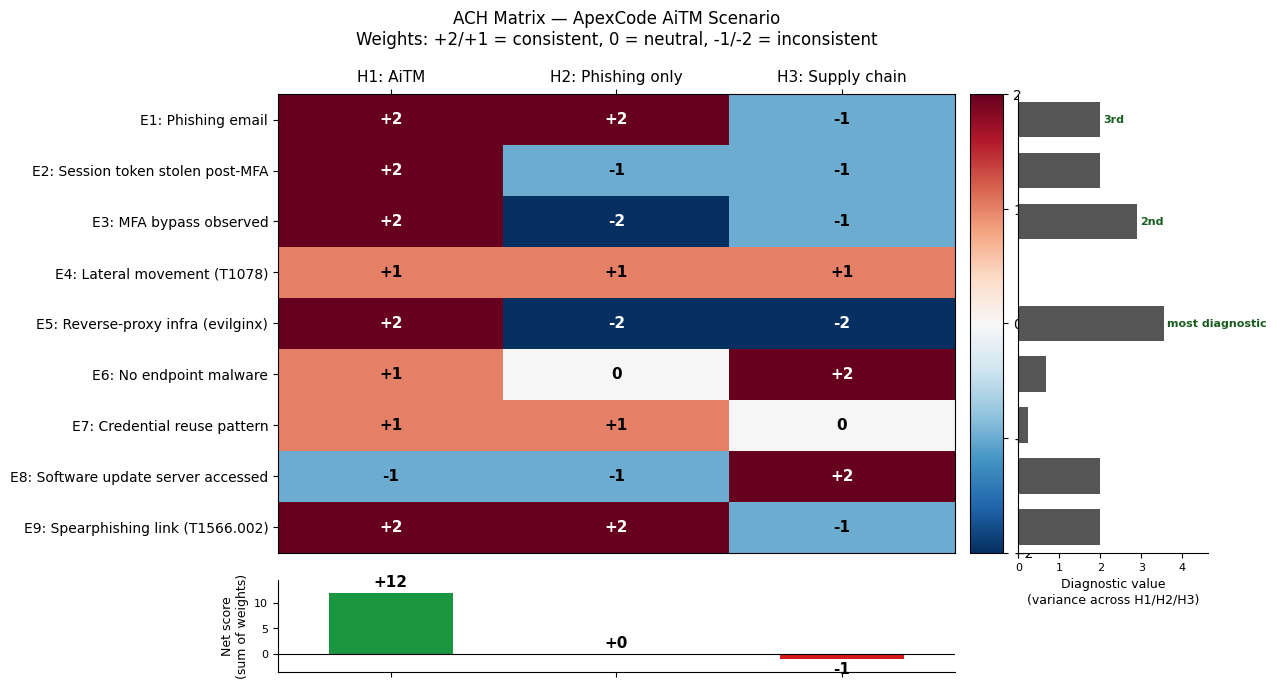


Conclusion: H1 (AiTM) net score +12 | H2 (Phishing only) +0 | H3 (Supply chain) -1.
Most diagnostic evidence: E5 (reverse-proxy infra), E3 (MFA bypass), E1 (phishing email).
Figure 13.8 = canonical Heuer-style matrix (analytical view).
Figure 13.9 = Sankey flow (executive briefing view of the same data).
Both mirror the ACH output the Ch9 SAT_Recommendation_Agent produces in natural language.


In [10]:
# ── ACH Argument Map — Matrix Heatmap + Sankey Flow View ────────────────────
# Scenario: ApexCode AiTM incident (from Ch 9)
# Three competing hypotheses, nine evidence items
# Figure 13.8: canonical Heuer-style ACH matrix with diagnosticity sidebar + net-score footer
# Figure 13.9: Sankey flow view (executive briefing form of the same data)

from matplotlib.gridspec import GridSpec

HYPOTHESES = {
    'H1': 'AiTM credential theft (adversary-in-the-middle)',
    'H2': 'Targeted spear-phishing (credential harvest, no session hijack)',
    'H3': 'Supply chain compromise (pre-positioned access, no phishing)',
}

EVIDENCE = {
    'E1': 'Phishing email detected targeting finance employee',
    'E2': 'Session token stolen post-MFA (not password)',
    'E3': 'MFA bypass observed — no second factor prompted',
    'E4': 'Lateral movement via T1078 (Valid Accounts)',
    'E5': 'Reverse proxy infrastructure identified (evilginx pattern)',
    'E6': 'No malware/implant found on endpoint',
    'E7': 'Credential reuse pattern across multiple accounts',
    'E8': 'Software update server accessed 72h before incident',
    'E9': 'T1566.002 (Spearphishing Link) observed in email logs',
}

# ACH matrix: keys = (hypothesis, evidence), values = consistency weight (-2 .. +2)
ach_matrix = {
    ('H1', 'E1'): +2,   # Phishing is the AiTM delivery mechanism
    ('H1', 'E2'): +2,   # Session token theft is the defining AiTM IOC
    ('H1', 'E3'): +2,   # MFA bypass is the core AiTM result
    ('H1', 'E4'): +1,   # Lateral movement consistent
    ('H1', 'E5'): +2,   # Reverse proxy is the AiTM infrastructure
    ('H1', 'E6'): +1,   # AiTM often leaves no endpoint malware
    ('H1', 'E7'): +1,   # Credential reuse weakly consistent
    ('H1', 'E8'): -1,   # Supply chain access inconsistent with AiTM
    ('H1', 'E9'): +2,   # Spearphishing link = AiTM delivery vector

    ('H2', 'E1'): +2,   # Phishing is the delivery mechanism
    ('H2', 'E2'): -1,   # Phishing harvests password, not session token
    ('H2', 'E3'): -2,   # MFA bypass not expected from password theft alone
    ('H2', 'E4'): +1,   # Lateral movement consistent
    ('H2', 'E5'): -2,   # No reverse proxy needed for standard phishing
    ('H2', 'E6'):  0,   # No malware not distinctive
    ('H2', 'E7'): +1,   # Credential reuse fits password theft
    ('H2', 'E8'): -1,   # Supply chain access inconsistent
    ('H2', 'E9'): +2,   # Spearphishing link consistent

    ('H3', 'E1'): -1,   # No phishing needed for supply chain
    ('H3', 'E2'): -1,   # Pre-positioning does not require post-MFA interception
    ('H3', 'E3'): -1,   # Pre-positioned implant bypasses authentication entirely
    ('H3', 'E4'): +1,   # Lateral movement consistent
    ('H3', 'E5'): -2,   # No reverse proxy in supply chain scenario
    ('H3', 'E6'): +2,   # Supply chain often has no endpoint malware
    ('H3', 'E7'):  0,   # Credential reuse not distinctive
    ('H3', 'E8'): +2,   # Software update server access is the supply chain IOC
    ('H3', 'E9'): -1,   # Spearphishing link inconsistent with supply chain
}

# Short labels for figure axes (full text appears in the chapter caption)
ev_short = {
    'E1': 'Phishing email',
    'E2': 'Session token stolen post-MFA',
    'E3': 'MFA bypass observed',
    'E4': 'Lateral movement (T1078)',
    'E5': 'Reverse-proxy infra (evilginx)',
    'E6': 'No endpoint malware',
    'E7': 'Credential reuse pattern',
    'E8': 'Software update server accessed',
    'E9': 'Spearphishing link (T1566.002)',
}
hyp_short = {'H1': 'H1: AiTM', 'H2': 'H2: Phishing only', 'H3': 'H3: Supply chain'}

ev_ids  = list(EVIDENCE.keys())
hyp_ids = list(HYPOTHESES.keys())
M = np.array([[ach_matrix[(h, e)] for h in hyp_ids] for e in ev_ids], dtype=float)
diag_var  = M.var(axis=1)         # per-evidence diagnostic value
net_score = M.sum(axis=0)         # per-hypothesis net score

# ── Analysis 1: Net consistency scores ─────────────────────────────────────
print("=" * 60)
print("NET CONSISTENCY SCORES (sum of evidence weights per hypothesis)")
print("=" * 60)
for j, hid in enumerate(hyp_ids):
    in_w = [ach_matrix[(hid, e)] for e in ev_ids]
    counts = {k: in_w.count(k) for k in [-2, -1, 0, 1, 2]}
    print(f"\n{hid}: {HYPOTHESES[hid]}")
    print(f"  Net score: {int(net_score[j]):+d}  | ++:{counts[2]}  +:{counts[1]}  "
          f"0:{counts[0]}  -:{counts[-1]}  --:{counts[-2]}")

# ── Analysis 2: Most diagnostic evidence (highest variance) ────────────────
print("\n" + "=" * 60)
print("DIAGNOSTIC EVIDENCE (highest variance across hypotheses)")
print("=" * 60)
diag_sorted = sorted(enumerate(diag_var), key=lambda x: -x[1])
for i, var in diag_sorted:
    eid = ev_ids[i]
    weights_str = "  ".join(f"{h}:{ach_matrix[(h,eid)]:+d}" for h in hyp_ids)
    print(f"  {eid} ({EVIDENCE[eid][:50]})")
    print(f"       {weights_str}  |  variance: {var:.2f}")

# ── Analysis 3: Hypothesis similarity ─────────────────────────────────────
print("\n" + "=" * 60)
print("HYPOTHESIS SIMILARITY (cosine similarity of evidence profiles)")
print("=" * 60)
from numpy.linalg import norm as npnorm
hyp_vecs = {h: np.array([ach_matrix[(h, e)] for e in ev_ids]) for h in hyp_ids}
for i, h1 in enumerate(hyp_ids):
    for h2 in hyp_ids[i+1:]:
        sim = np.dot(hyp_vecs[h1], hyp_vecs[h2]) / (npnorm(hyp_vecs[h1]) * npnorm(hyp_vecs[h2]) + 1e-9)
        print(f"  {h1} vs {h2}: {sim:+.3f}  ({'similar — hard to distinguish' if sim > 0.5 else 'distinct'})")

# ── Figure 13.8: Matrix heatmap + diagnosticity sidebar + net-score footer ─
fig = plt.figure(figsize=(12, 7.5))
gs = GridSpec(2, 3, width_ratios=[5, 0.25, 1.4], height_ratios=[5, 1],
              hspace=0.10, wspace=0.05, figure=fig)
ax_main = fig.add_subplot(gs[0, 0])
ax_cbar = fig.add_subplot(gs[0, 1])
ax_diag = fig.add_subplot(gs[0, 2])
ax_net  = fig.add_subplot(gs[1, 0])
fig.add_subplot(gs[1, 1]).axis('off')
fig.add_subplot(gs[1, 2]).axis('off')

im = ax_main.imshow(M, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto', origin='upper')
ax_main.set_xticks(range(len(hyp_ids)))
ax_main.set_xticklabels([hyp_short[h] for h in hyp_ids], fontsize=11)
ax_main.set_yticks(range(len(ev_ids)))
ax_main.set_yticklabels([f'{e}: {ev_short[e]}' for e in ev_ids], fontsize=10)
ax_main.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
for i in range(len(ev_ids)):
    for j in range(len(hyp_ids)):
        v = int(M[i, j])
        ax_main.text(j, i, f'{v:+d}' if v != 0 else '0',
                     ha='center', va='center',
                     color='white' if abs(v) == 2 else 'black',
                     fontsize=11, fontweight='bold')
ax_main.set_title("ACH Matrix — ApexCode AiTM Scenario\n"
                  "Weights: +2/+1 = consistent, 0 = neutral, -1/-2 = inconsistent",
                  fontsize=12, pad=18)

ax_diag.barh(range(len(ev_ids)), diag_var, color='#555', height=0.7)
ax_diag.set_ylim(ax_main.get_ylim())
ax_diag.set_xlabel('Diagnostic value\n(variance across H1/H2/H3)', fontsize=9)
ax_diag.tick_params(axis='y', labelleft=False, left=False)
ax_diag.tick_params(axis='x', labelsize=8)
ax_diag.set_xlim(0, max(diag_var) * 1.30)
ax_diag.spines[['top', 'right']].set_visible(False)
top3 = np.argsort(-diag_var)[:3]
for rank, idx in enumerate(top3):
    ax_diag.text(diag_var[idx] + max(diag_var) * 0.02, idx,
                 ['most diagnostic', '2nd', '3rd'][rank],
                 va='center', fontsize=8, color='#1a5e1f', fontweight='bold')

colors_net = ['#1a9641' if s > 0 else '#d7191c' if s < 0 else '#999' for s in net_score]
ax_net.bar(range(len(hyp_ids)), net_score, color=colors_net, width=0.55)
ax_net.axhline(0, color='black', linewidth=0.8)
ax_net.set_ylabel('Net score\n(sum of weights)', fontsize=9)
ax_net.set_xticks(range(len(hyp_ids)))
ax_net.set_xticklabels([])
ax_net.set_xlim(-0.5, len(hyp_ids) - 0.5)
for j, s in enumerate(net_score):
    ax_net.text(j, s + (0.6 if s >= 0 else -0.6), f'{int(s):+d}',
                ha='center', va='bottom' if s >= 0 else 'top',
                fontsize=11, fontweight='bold')
ax_net.spines[['top', 'right']].set_visible(False)
ax_net.tick_params(axis='y', labelsize=8)
ax_net.set_ylim(net_score.min() - 2.5, net_score.max() + 2.5)

cb = fig.colorbar(im, cax=ax_cbar)
cb.set_label('Consistency weight', fontsize=9)
cb.set_ticks([-2, -1, 0, 1, 2])
plt.savefig(IMAGES_DIR / 'figure_13_8_ach_argument_map.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Figure 13.9: Sankey flow view (executive briefing form) ─────────────────
node_labels = [f'{e}: {ev_short[e]}' for e in ev_ids] + [hyp_short[h] for h in hyp_ids]
n_ev, n_hyp = len(ev_ids), len(hyp_ids)
# Lighter node fills so the in-node labels are legible at print scale.
node_colors = ['#f7f7f7'] * n_ev + ['#deebf7'] * n_hyp

sources, targets, values, link_colors, link_labels = [], [], [], [], []
for i, e in enumerate(ev_ids):
    for j, h in enumerate(hyp_ids):
        w = ach_matrix[(h, e)]
        if w == 0:
            continue
        sources.append(i); targets.append(n_ev + j); values.append(abs(w))
        rgb = '26, 150, 65' if w > 0 else '215, 25, 28'
        link_colors.append(f'rgba({rgb}, {0.45 + 0.22 * abs(w)})')
        link_labels.append(f'{e} → {h}: weight {w:+d}')

fig_sankey = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(pad=28, thickness=22, line=dict(color='black', width=1.0),
              label=node_labels, color=node_colors),
    link=dict(source=sources, target=targets, value=values,
              color=link_colors, label=link_labels,
              hovertemplate='%{label}<extra></extra>'),
))
fig_sankey.update_layout(
    title=dict(text='ACH Flow View — Evidence Supporting (green) vs Refuting (red) Each Hypothesis<br>'
                    '<sub>Flow width = |consistency weight|; opacity = strength; neutral (0) links omitted</sub>',
               x=0.5, xanchor='center', font=dict(size=22)),
    font=dict(size=20, color='#000'),
    height=1400, width=2200, margin=dict(l=40, r=40, t=140, b=40),
    paper_bgcolor='white',
)
# Print-readable Sankey: white evidence-node fills + 20pt font + 2200x1400 canvas at
# scale=3 produces a 6600x4200 PNG whose labels remain legible after Packt scales the
# image down to a 6-inch column. Prior 1600x900/15pt iteration had labels washed out
# against gray fills — DataViz review flagged it as a print blocker.
fig_sankey.write_image(IMAGES_DIR / 'figure_13_9_ach_sankey.png', width=2200, height=1400, scale=3)
fig_sankey.show()

print("\nConclusion: H1 (AiTM) net score +12 | H2 (Phishing only) +0 | H3 (Supply chain) -1.")
print("Most diagnostic evidence: E5 (reverse-proxy infra), E3 (MFA bypass), E1 (phishing email).")
print("Figure 13.8 = canonical Heuer-style matrix (analytical view).")
print("Figure 13.9 = Sankey flow (executive briefing view of the same data).")
print("Both mirror the ACH output the Ch9 SAT_Recommendation_Agent produces in natural language.")


---
## Insider Threat Feature Engineering — Paper 8 Concepts Applied Correctly

**Intelligence cycle connection:** Insider threat detection operates at the Collection and Analysis stages — organizational log data (logon, file, device, HTTP, email) is the raw input, and behavioral deviation from a user's baseline is the signal. Paper 8 (Lavanya et al. 2025) contributes a sound temporal feature engineering schema for this problem: Normal Window (NW, business hours 8am–6pm) versus Abnormal Window (ABW, after-hours) time splitting, with nine aggregated temporal features that capture behavioral deviation at multiple time scales.

**What this cell demonstrates:** The feature engineering concept Paper 8 gets right — not the evaluation methodology it gets wrong. We generate synthetic user activity logs with realistic NW/ABW patterns, build the nine temporal features from Paper 8's Table 3, and show how the feature schema surfaces behavioral deviation that raw event counts miss. The CMU CERT dataset requires a license agreement; the synthetic data here reproduces the feature schema for pedagogical purposes.

**What this cell does NOT demonstrate:** The GAN-based oversampling, the AGCN classifier, or the accuracy-based evaluation — all of which the chapter critiques in §13.1. The evaluation harness from §13.2 (temporal splits, PR-AUC, baseline comparison) applies to insider threat detection identically.

Synthetic activity logs: 18,000 rows (200 users × 90 days, 5 insiders)
Insider user IDs: [np.int64(15), np.int64(30), np.int64(95), np.int64(128), np.int64(158)]

Temporal feature matrix: 200 users × 9 features

Feature schema (Paper 8, Table 3 adapted):
  hr_day_nw           normal=18.642  insider=18.856  ratio=1.01
  hr_day_abw          normal=1.991  insider=5.762  ratio=2.89 ← separating
  day_week_nw         normal=0.963  insider=0.962  ratio=1.00
  day_week_abw        normal=0.866  insider=0.927  ratio=1.07
  hr_week_nw          normal=129.058  insider=130.538  ratio=1.01
  hr_week_abw         normal=13.782  insider=39.892  ratio=2.89 ← separating
  week_month_nw       normal=0.963  insider=0.962  ratio=1.00
  week_month_abw      normal=0.866  insider=0.927  ratio=1.07
  abw_ratio           normal=0.096  insider=0.234  ratio=2.43 ← separating


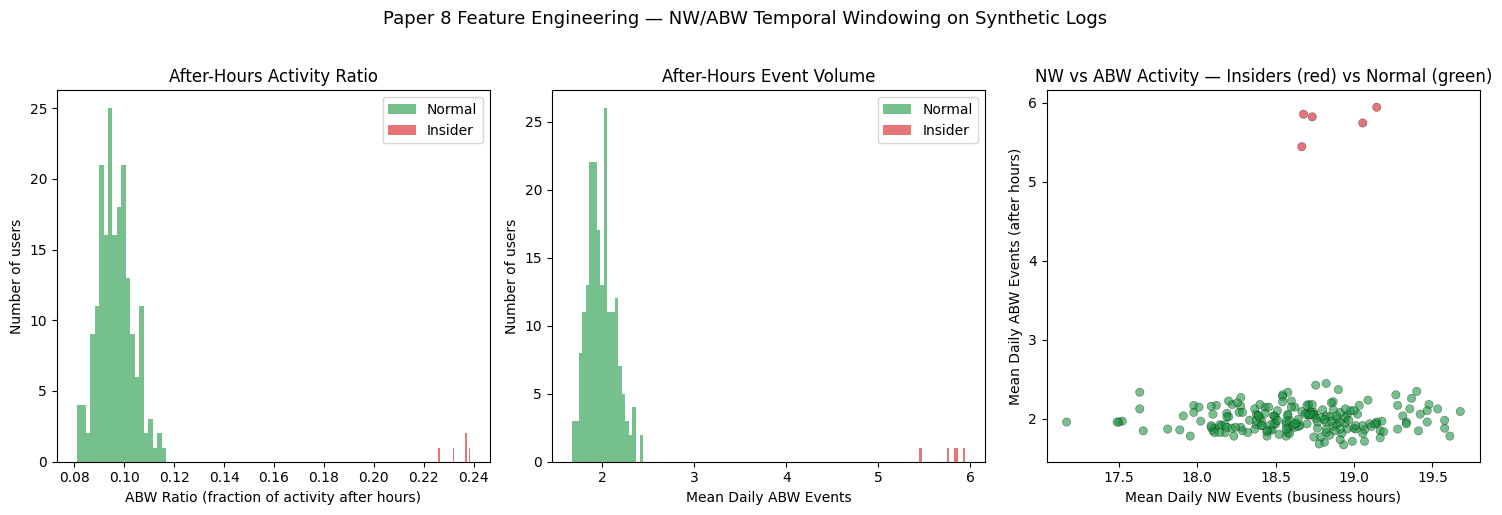


Key takeaway: The NW/ABW temporal windowing and aggregated features are
operationally sound — they surface behavioral deviation that raw event
counts miss. The feature schema transfers to any organizational log dataset.
What matters is evaluating the downstream model correctly: temporal splits,
PR-AUC, and baseline comparison per §13.2 — not the accuracy metric Paper 8 uses.


In [11]:
# ── Insider Threat Feature Engineering — Paper 8 Schema ──────────────────────
# Generates synthetic user activity logs, builds the NW/ABW temporal feature
# schema from Paper 8 (Lavanya et al. 2025, Table 3), and visualizes how
# the features surface behavioral deviation that raw event counts miss.

np.random.seed(42)

N_USERS = 200
N_DAYS  = 90   # 3 months of activity
N_INSIDERS = 5
INSIDER_IDS = set(np.random.choice(N_USERS, N_INSIDERS, replace=False))

# ── Generate synthetic activity logs ─────────────────────────────────────────
# Normal users: mostly business-hours activity (8am-6pm), occasional after-hours
# Insiders: elevated after-hours activity, especially in final weeks

rows = []
for user_id in range(N_USERS):
    is_insider = user_id in INSIDER_IDS
    for day in range(N_DAYS):
        dt = pd.Timestamp('2024-01-01') + pd.Timedelta(days=day)
        weekday = dt.weekday()  # 0=Mon, 6=Sun

        # Normal window (NW): 8am-6pm — business hours
        if weekday < 5:  # weekdays
            nw_events = np.random.poisson(lam=25)
        else:  # weekends
            nw_events = np.random.poisson(lam=2)

        # Abnormal window (ABW): before 8am or after 6pm
        if is_insider and day > N_DAYS * 0.6:
            # Insider ramp-up: elevated after-hours in final 40% of observation
            abw_events = np.random.poisson(lam=12)
        else:
            abw_events = np.random.poisson(lam=2)

        rows.append({
            'user_id':    user_id,
            'date':       dt,
            'weekday':    weekday,
            'nw_events':  nw_events,
            'abw_events': abw_events,
            'is_insider': int(is_insider),
        })

logs = pd.DataFrame(rows)
logs['week']  = logs['date'].dt.isocalendar().week.astype(int)
logs['month'] = logs['date'].dt.month

print(f"Synthetic activity logs: {len(logs):,} rows "
      f"({N_USERS} users × {N_DAYS} days, {N_INSIDERS} insiders)")
print(f"Insider user IDs: {sorted(INSIDER_IDS)}")

# ── Build Paper 8's 9 temporal features (Table 3) ───────────────────────────
# Each feature aggregates activity at a different time scale, split by NW/ABW.
# The schema captures deviation: an insider with normal daily volume but
# abnormal after-hours concentration will show up in ABW features.

def build_temporal_features(df):
    """Build the 9-feature schema from Paper 8 Table 3, per user."""
    feats = df.groupby('user_id').agg(
        # Hours per day accessed (NW vs ABW)
        hr_day_nw  = ('nw_events',  'mean'),
        hr_day_abw = ('abw_events', 'mean'),

        # Days per week accessed (NW vs ABW) — fraction of days with >0 events
        day_week_nw  = ('nw_events',  lambda x: (x > 0).mean()),
        day_week_abw = ('abw_events', lambda x: (x > 0).mean()),

        # Total hours per week (sum of events / number of weeks)
        hr_week_nw   = ('nw_events',  'sum'),
        hr_week_abw  = ('abw_events', 'sum'),

        # Weeks per month active (fraction of weeks with any activity)
        week_month_nw  = ('nw_events',  lambda x: (x > 0).sum() / max(1, len(x))),
        week_month_abw = ('abw_events', lambda x: (x > 0).sum() / max(1, len(x))),

        # Ground truth
        is_insider = ('is_insider', 'first'),
    ).reset_index()

    n_weeks = df['week'].nunique()
    feats['hr_week_nw']  /= max(1, n_weeks)
    feats['hr_week_abw'] /= max(1, n_weeks)

    # Derived: ABW ratio — fraction of total activity occurring after hours
    feats['abw_ratio'] = (feats['hr_day_abw'] /
                          (feats['hr_day_nw'] + feats['hr_day_abw'] + 1e-9))

    return feats

user_feats = build_temporal_features(logs)
feature_cols = [c for c in user_feats.columns if c not in ('user_id', 'is_insider')]

print(f"\nTemporal feature matrix: {user_feats.shape[0]} users × {len(feature_cols)} features")
print(f"\nFeature schema (Paper 8, Table 3 adapted):")
for col in feature_cols:
    insider_mean = user_feats.loc[user_feats['is_insider']==1, col].mean()
    normal_mean  = user_feats.loc[user_feats['is_insider']==0, col].mean()
    ratio = insider_mean / (normal_mean + 1e-9)
    flag = ' ← separating' if abs(ratio - 1) > 0.3 else ''
    print(f"  {col:<18s}  normal={normal_mean:.3f}  insider={insider_mean:.3f}  "
          f"ratio={ratio:.2f}{flag}")

# ── Visualize: NW vs ABW deviation ───────────────────────────────────────────
fig_it, axes_it = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: ABW ratio distribution (insiders vs normal)
for label, grp in user_feats.groupby('is_insider'):
    name = 'Insider' if label == 1 else 'Normal'
    color = '#d7191c' if label == 1 else '#1a9641'
    axes_it[0].hist(grp['abw_ratio'], bins=20, alpha=0.6, label=name, color=color)
axes_it[0].set_xlabel('ABW Ratio (fraction of activity after hours)')
axes_it[0].set_ylabel('Number of users')
axes_it[0].set_title('After-Hours Activity Ratio')
axes_it[0].legend()

# Panel 2: Mean daily ABW events
for label, grp in user_feats.groupby('is_insider'):
    name = 'Insider' if label == 1 else 'Normal'
    color = '#d7191c' if label == 1 else '#1a9641'
    axes_it[1].hist(grp['hr_day_abw'], bins=20, alpha=0.6, label=name, color=color)
axes_it[1].set_xlabel('Mean Daily ABW Events')
axes_it[1].set_ylabel('Number of users')
axes_it[1].set_title('After-Hours Event Volume')
axes_it[1].legend()

# Panel 3: Scatter — NW vs ABW mean daily events
colors = ['#d7191c' if x == 1 else '#1a9641' for x in user_feats['is_insider']]
axes_it[2].scatter(user_feats['hr_day_nw'], user_feats['hr_day_abw'],
                   c=colors, alpha=0.6, edgecolors='black', linewidths=0.3)
axes_it[2].set_xlabel('Mean Daily NW Events (business hours)')
axes_it[2].set_ylabel('Mean Daily ABW Events (after hours)')
axes_it[2].set_title('NW vs ABW Activity — Insiders (red) vs Normal (green)')

plt.suptitle("Paper 8 Feature Engineering — NW/ABW Temporal Windowing on Synthetic Logs",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'insider_threat_features.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey takeaway: The NW/ABW temporal windowing and aggregated features are")
print("operationally sound — they surface behavioral deviation that raw event")
print("counts miss. The feature schema transfers to any organizational log dataset.")
print("What matters is evaluating the downstream model correctly: temporal splits,")
print("PR-AUC, and baseline comparison per §13.2 — not the accuracy metric Paper 8 uses.")

---
## Synthesis — Classical ML and LLMs in the Intelligence Lifecycle

The ApexCode incident from Chapters 6–12 began with a single QIR and ended with the CISO surfacing two follow-on concerns the analyst decomposed into three operational sub-questions plus a forward-looking forecast. The six experiments in this notebook answer them — not because the notebook was built for ApexCode, but because the sub-questions the analyst surfaced from those two CISO concerns are the same questions every mature threat intelligence program eventually asks. Which CVEs should we triage first? Which are being exploited now, and why did each score high? Which actor is most likely responsible? Is our threat surface growing? The analyst reasoned through the incident across Chapters 6 through 12, scaffolded by an LLM-based AI tool at each stage; classical ML in this notebook answers the population-level questions the incident generated.

The six use cases in this notebook show where classical ML provides durable value across the intelligence cycle:

| Stage | ML Output | Why Not LLM Here |
|---|---|---|
| Collection (Ch 7) | Ranked CVE list (score per indicator) | LLMs score one item at a time; ML ranks tens of thousands at once |
| Analysis (Ch 9) | Exploitation probability per CVE | Calibrated probability requires training data, not prompt engineering |
| Analysis (Ch 9) | Actor similarity ranking (Jaccard TTP clustering) | Deterministic set-overlap distance on structured data; LLM adds no value |
| Production (Ch 10) | SHAP-attributed exploitation score | Explainability requires glass-box model, not LLM chain-of-thought |
| Feedback (Ch 12) | Weekly disclosure volume forecast | Time series regression; LLMs have no native time awareness |
| Analysis (Ch 9) | ACH matrix + Sankey flow view | Quantitative diagnosticity and per-hypothesis net scores LLMs cannot reliably produce from prompt context |

**The complementary case:**  
LLMs (Chapters 6–12) handle what classical ML cannot: ambiguous natural language reasoning, multi-step analytic judgment, narrative synthesis, and structured output from unstructured text. The mature CTI program runs both — ML for scale and quantification, LLMs for reasoning and communication.
